
# 한국어 챗봇 Transformer — 모델 설계

## Task
송영숙 ChatbotData (한국어 일상/이별/사랑 카테고리 12k 쌍)로 한국어 챗봇 학습.

## 모델 아키텍처: Decoder-only Transformer

### 왜 Decoder-only인가
노드 자료는 인코더-디코더 구조였지만 챗봇이라는 특성상 생성모델에 속하기 때문에 디코더 중심이 더 나을거라는 생각을 했기 때문이다. 
그리고 솔직히 디코더 중심 모델을 한번 만들어보고 싶었다는 욕심도 있었다. 


| 항목 | Encoder-Decoder | Decoder-only (선택) |
|--|--|--|
| 구조 | Encoder + Decoder + Cross-attn | Decoder만 |
| Q를 보는 방식 | 양방향 (bidirectional) | 단방향 (causal) |
| 학습 방식 | seq2seq | Causal LM (다음 토큰 예측) |
| 현대 LLM | 거의 안 씀 | **표준 (GPT, LLaMA, Claude)** |


- 챗봇 = autoregressive 생성 task → decoder-only가 자연스러움
- Q, A 모두 한국어 → 같은 토크나이저·임베딩 공유 가능
- 구조 단순 (cross-attention 없음, mask 한 종류)
- LLM 표준에 가까운 학습 경험

## 핵심 디자인 결정

여기서는 현재 사용중인 모델의 구조를 많이 참고했다. 
기본적으로 위치인코딩도 RoPE라는 방식을 써 봤는데 배운것과 실제로 적용하는것은 천지차이라는 것을 깨달을 수가 있었다... 


| 항목 | 선택 | 근거 |
|--|--|--|
| Tokenizer | SentencePiece BPE (vocab 8000) | 한국어 교착어 특성, OOV 강건성 |
| Special tokens | [SOS], [SEP], [EOS], [PAD], [UNK] | Q-A 경계 명시, decoder-only 표준 |
| Positional Encoding | **RoPE** (LLaMA 스타일) | 학습 동기, 현대 LLM 표준 |
| Normalization | **Pre-LN** | 학습 안정성, warmup 부담 ↓ |
| Activation | ReLU | 단순, 충분 |
| Embedding tying | **O** | 입출력 같은 vocab, 파라미터 절약 |

## 모델 크기 (작은 데이터 12k에 맞춰 작게)

모델 크기에 대해서는 데이터셋을 확인하고 가능하면 작은 모델을 작성하기로 했다. 
어차피 모델이 커도 로컬에서 학습도 어려울 것이었고 적은 데이터셋이니만큼 작은 모델로 시도해야 제대로 학습이 될거라는 생각이 들었기 때문이다 


| 파라미터 | 값 |
|--|--|
| d_model | 256 |
| num_layers | 3 |
| num_heads | 8 (head_dim=32) |
| d_ff | 1024 |
| MAX_LEN | 64 |
| Dropout | 0.1 |
| **총 파라미터** | **4.4M** |

## 데이터 시퀀스 구조

```
입력 시퀀스:
[SOS] Q토큰들 [SEP] A토큰들 [EOS] [PAD] ...
  ↑              ↑              ↑
시작 신호      경계 신호      종료 신호

학습 방식:
- Input  = sequence[:-1]   ← 모델이 보는 것 (Causal LM teacher forcing)
- Target = sequence[1:]    ← 다음 토큰 예측

Loss masking:
- Q + [SEP] 영역: 학습 X (label = -100)
- A + [EOS] 영역: 학습 O
```

## 전체 데이터 흐름

```
input_ids (B, L)
    ↓
TokenEmbedding → (B, L, 256)
    ↓
EmbedDropout
    ↓
┌──────────────────────────────────────┐
│ DecoderBlock × 3                     │
│   Pre-LN: x = x + dropout(            │
│           MHA(norm1(x), mask, RoPE))  │
│   Pre-LN: x = x + dropout(FFN(norm2(x)))│
│                                       │
│   MHA: Q/K에 RoPE, V는 그대로        │
│        Causal + Padding mask           │
└──────────────────────────────────────┘
    ↓
Final LayerNorm
    ↓
LM Head (tied with TokenEmbedding) → (B, L, 8000)
    ↓
Softmax → 다음 토큰 확률
```

## 학습 셋업

| 항목 | 값 |
|--|--|
| Optimizer | AdamW (β=0.9/0.95, weight_decay=0.01) |
| LR Scheduler | Warmup 10% + Cosine decay |
| Initial LR | 5e-4 |
| Batch size | 64 |
| Epochs | 20 |
| Gradient clip | 1.0 |
| Label smoothing | 0.1 |
| Loss | CrossEntropy (ignore_index=-100) |

## 평가 방식

- **Train/Valid PPL** — 학습 진행도 모니터링
- **Unseen Q 11개로 정성평가** — 일반화 능력 측정
- **Greedy + Sampling 비교** — 분포 sharpness 확인
- **임베딩 진단 + Attention 진단** — 메커니즘 vs 데이터 문제 분리

---
```



### EDA 

기본적인 데이터를 확인해주는 작업이다. 가장 처음은 데이터셋을 받아 직접 열어서 확인해보는 일이었다. 
데이터는 깔끔하고 각 문장의 끝에 0,1,2 라는 번호로 라벨링이 되어있었다. 

데이터량이 극단적으로 적다고 생각했기 때문에, 여기서 얻은 내용을 바탕으로 기본적인 모델의 청사진을 만들어 나갔다. 

1. 우선 가장 기본적으로 길이 평균이 13자 정도였다는 점, 그래프 분포를 봤을 때 40까지는 최대길이를 잡는 편이 좋겠다는 생각이 들었다. 40까지는 그래프의 꼬리가 남아있었기 때문이다. 
2. 전체 데이터는 11,000 쌍 정도라는 것, 약 1.2k 정도 되는 데이터량은 언어모델, 챗봇을 만드는 데는 치명적으로 작은 양이라는  생각이 들었다. 그래서 루브릭 기준 3만 정도를 잡더라도 학습으로는 조금 모자라다 싶어 모델의 크기를 줄이기로 결정한다. 
3. 0,1,2 라는 번호로 라벨링이 되어있는 것은 특정 상황에 맞춰져 있었다는 점, (일상/이별/사랑)순으로 구성되어있었는데 자연스러운 대화를 나누기에는 다소 데이터셋의 폭이 좁다는 생각을 했다.
4. 답변 1.2만의 데이터 중 중복의 비율이 상당히 크다는 점은 치명적이었다. 이것은 답변의 풀이 좁고, 답변 자체에 과적합이 있을지도 모르겠다는 것을 암시했다. 

p95={df['Q_len'] 이 부분은 길이를 구하는데 조금 고민하게 만든 부분이었음 
이미 그래프로 길이 30 이상인 값들이 거의 없다는 것을 알고 있었기 때문에 좀 더 정확한 값을 알기 위해 따로 코드를 통해 데이터의 95퍼센트의 최대길이가 25정도라는 것을 알게 됨 
이것은 사실 최대길이의 적정선이 25~30정도라는 것을 알게 해주었다. 실제 그래프도 30이후로 값이 급격하게 떨어지기 때문이기도 했었지만, 데이터셋의 규모가 워낙 작아서 나는 개인적으로 데이터셋을 모두 살리고 싶었기 때문에 최대길이를 조금 더 길게 잡았다. 

당연히 좋은것만 있는 것은 아니었다. 이럴경우 짧은 토큰 뒤에는 패딩을 붙여줘야 하기 때문에 어텐션 계산 과정중에 불필요한 연산이 생기게 될 것이다. 


전체 데이터: 11,823쌍

label 분포 (0:일상 / 1:이별 / 2:사랑)
label
0    5290
1    3570
2    2963
Name: count, dtype: int64


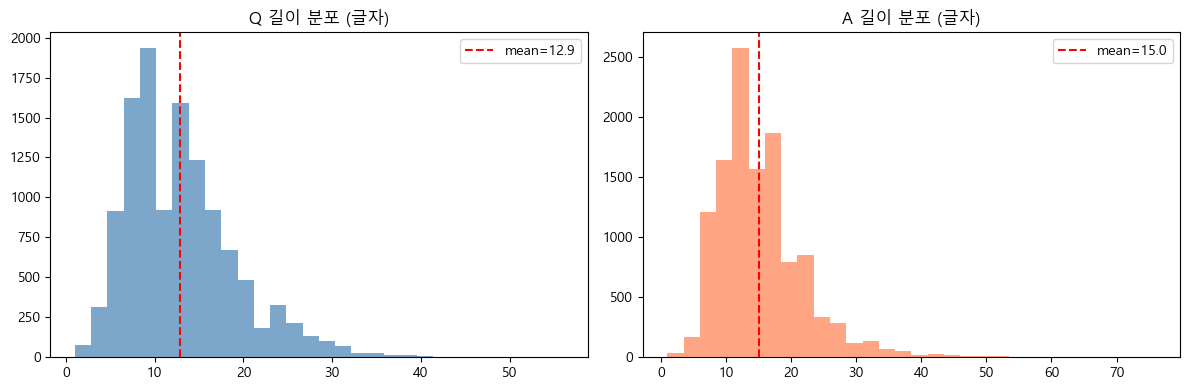


Q 길이: min=1, max=56, p95=25
A 길이: min=1, max=76, p95=27

중복 Q: 161
중복 A: 4044  ← unique A: 7779

=== 라벨별 샘플 ===

[label=0]
          Q             A
    꽃 받고 싶다   제가 드리고 싶네요.
 데려다 주지도 않고     많이 바쁜가봐요.
새신발 신었는데 비와 얼른 실내로 들어가세요.

[label=1]
              Q            A
끝날때까지 끝난게 아니라지만  끝이 보이고 있나요.
      아직도 그대로인걸 변하는 건 사랑이겠죠.
  그녀에게 연락이 왔습니다    싱숭생숭했겠네요.

[label=2]
                     Q                         A
좋아하는 남자의 단점을 들었는데도 좋아.           사랑의 콩깍지가 씌었나봐요.
       썸 타기 좋은 알바 뭐있음?          함께 돕는 알바를 찾아보세요.
돈이 없으면 연애를 하지않는게 맞는걸까. 돈 없어도 할 수 있는 데이트 코스도 많아요.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path(r"C:\Users\akals\Downloads\korean-english-park.train\chatbot\ChatbotData.csv")
df = pd.read_csv(DATA_PATH)

print(f"전체 데이터: {len(df):,}쌍")
print(f"\nlabel 분포 (0:일상 / 1:이별 / 2:사랑)")
print(df['label'].value_counts().sort_index())

# 길이 분포
df['Q_len'] = df['Q'].str.len()
df['A_len'] = df['A'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Q_len'], bins=30, color='steelblue', alpha=0.7)
axes[0].set_title('Q 길이 분포 (글자)')
axes[0].axvline(df['Q_len'].mean(), color='red', linestyle='--', label=f"mean={df['Q_len'].mean():.1f}")
axes[0].legend()

axes[1].hist(df['A_len'], bins=30, color='coral', alpha=0.7)
axes[1].set_title('A 길이 분포 (글자)')
axes[1].axvline(df['A_len'].mean(), color='red', linestyle='--', label=f"mean={df['A_len'].mean():.1f}")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"\nQ 길이: min={df['Q_len'].min()}, max={df['Q_len'].max()}, p95={df['Q_len'].quantile(0.95):.0f}")
print(f"A 길이: min={df['A_len'].min()}, max={df['A_len'].max()}, p95={df['A_len'].quantile(0.95):.0f}")
print(f"\n중복 Q: {df['Q'].duplicated().sum()}")
print(f"중복 A: {df['A'].duplicated().sum()}  ← unique A: {df['A'].nunique()}")

# 샘플
print("\n=== 라벨별 샘플 ===")
for lbl in [0, 1, 2]:
    print(f"\n[label={lbl}]")
    print(df[df['label']==lbl].sample(3, random_state=42)[['Q','A']].to_string(index=False))

### 데이터 노이즈 확인 

사실 육안으로 확인했을 때도 데이터셋이 깔끔하게 정리되어 있었기 때문에 굳이 노이즈를 찾을 필요는 없다고 생각했지만 
그래도 노이즈를 확인해 보자 몇가지 특징점이 잡혔다. 중요한 것은 초성어로 이뤄진 이모티콘들이나 특수문자가 있었다. 
처음에는 전부 지워버릴까 생각을 했지만 지워버리는 것 보단 차라리 하나로 통일시키는게 좋겠다는 생각을 했다. 
예를 들어 ㅋ가 여러개면 2개로 맞춰서 공통된 신호로 만들면 학습을 할 수도 있지 않을까? 라는 생각이었음 


In [10]:
# 데이터 노이즈 빠르게 확인
import re

# 한글/영문/숫자/기본구두점 외 문자 찾기
def find_special(text):
    return re.findall(r'[^가-힣a-zA-Z0-9\s\.\,\?\!]', str(text))

df['Q_special'] = df['Q'].apply(find_special)
df['A_special'] = df['A'].apply(find_special)

# 특수문자 있는 샘플
print("Q에 특수문자 있는 샘플:")
print(df[df['Q_special'].apply(len) > 0].head(10)[['Q', 'Q_special']].to_string())
print("\nA에 특수문자 있는 샘플:")
print(df[df['A_special'].apply(len) > 0].head(10)[['A', 'A_special']].to_string())

Q에 특수문자 있는 샘플:
                    Q Q_special
7      SNS 맞팔 왜 안하지ㅠㅠ    [ㅠ, ㅠ]
211      공무원 시험 힘들어ㅠㅠ    [ㅠ, ㅠ]
592         나는 좋은데 ….       […]
1153  단둘이는 처음 만나는 날ㅋㅋ    [ㅋ, ㅋ]
1398        떠나요~ 제주도~    [~, ~]
1902      바람쐬러 정동진가~~    [~, ~]
2059         베터리 15%야       [%]
2060      베터리 겨우 15%야       [%]
2104     보일러 틀고 나갔어ㅠㅠ    [ㅠ, ㅠ]
2229          비트코인 ㅜㅜ    [ㅜ, ㅜ]

A에 특수문자 있는 샘플:
                      A A_special
100    밥 사줄 친구를 찾아 보세요~       [~]
468    밥 사줄 친구를 찾아 보세요~       [~]
701   시원한 물이라도 한 잔 드세요~       [~]
954   시원한 물이라도 한 잔 드세요~       [~]
1300               퍼가요~       [~]
1313               퍼가요~       [~]
1932     음~ 곰곰히 생각해보세요.       [~]
1933     음~ 곰곰히 생각해보세요.       [~]
4749       뭘 다운 받으신 건지…       […]
4750       뭘 다운 받으신 건지…       […]


In [11]:
import re

def normalize_text(text):
    text = str(text)
    # 반복 자모 → 2개로 통일 (ㅠㅠㅠ → ㅠㅠ, ㅋㅋㅋ → ㅋㅋ)
    text = re.sub(r'([ㅠㅜㅋㅎㅡ])\1{2,}', r'\1\1', text)
    # 반복 특수문자 → 1개로 통일 (~~ → ~, !!! → !)
    text = re.sub(r'([~!?.])\1{2,}', r'\1', text)
    # 공백 정규화
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Q'] = df['Q'].apply(normalize_text)
df['A'] = df['A'].apply(normalize_text)

# 확인
print("정규화 후 샘플:")
print(df.iloc[[7, 211, 1153, 1398]][['Q','A']].to_string())

정규화 후 샘플:
                    Q                    A
7      SNS 맞팔 왜 안하지ㅠㅠ     잘 모르고 있을 수도 있어요.
211      공무원 시험 힘들어ㅠㅠ     철밥통 되기가 어디 쉽겠어요.
1153  단둘이는 처음 만나는 날ㅋㅋ  서로를 아는 좋은 기회가 되겠네요.
1398        떠나요~ 제주도~               여행 좋죠!


### 전처리 + 토크나이저 학습 

우선 전처리로 초성어를 간단히 정규화를 해준 뒤, 토크나이저를 정했다. 
토크나이저 선택에는 3가지가 있었다. 
1. Word-level 띄어쓰기 단어 
2. Mecab 형태소로 
3. SentencePiece BPE 서브워드 위주로 

노드에서는 띄어쓰기 위주로 했었지만 사실 그렇게 좋은 선택은 아니지 않을까 하는 생각이었다. 한국어는 기본 띄어쓰기가 많기도 했고 ~을, ~를, ~가, 등등의 조사나 어미가 많이 붙기 때문에 오히려 서브워드 위주로 하는게 어떨까 하는 마음이 있었다. 
사실  그런 의미에서는 Mecab이 가장 깔끔하지만 Mecab은 이전 RNN에서 썼었기 때문에 이번에는 BPE 서브워드 위주로 접근하기로 했다. 

Vocab 사이즈는 8천으로 정했다. 
작은 모델로 진행하기로 했기 때문에 그렇게 크게 잡니는 않았다. 일반적으로도 코퍼스 크기의 / 3~5 정도라는 정보가 있었기도 했지만 
결국 보캡 사이즈 x 256을 통해 임베딩 파라미터가 결정되기 때문이었다. 너무 크게 잡으면 잡을수록 모델 내부 표현 차원(d_model)이 커지는데 학습에서는 매우 불리하고 안그래도 과적합이 날텐데 그런 위험을 더욱 늘려주는 꼴이었다. 

너무 크면:
임베딩 파라미터 폭증, 빈도 낮은 토큰들이 학습 안 됨 (long tail)
너무 작으면:
단어가 너무 잘게 쪼개짐 → 의미 손실, 시퀀스 길이 ↑ 

user_defined_symbols=['[SEP]'] 
이 부분은 SentencePiece에 그냥 텍스트로 넣으면 형태소로 쪼개버리기 때문에 특수 토큰이 쪼개지는 문제가 생기기 때문에 따로 처리를 한것 특수토큰이기때문에 따로 넘버링도 4번이 된다. 




In [12]:

# Cell 2: 전처리 + Tokenizer 학습
import re
import sentencepiece as spm

# 1 정규화
def normalize_text(text):
    text = str(text)
    text = re.sub(r'([ㅠㅜㅋㅎㅡ])\1{2,}', r'\1\1', text)
    text = re.sub(r'([~!?.])\1{2,}', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Q'] = df['Q'].apply(normalize_text)
df['A'] = df['A'].apply(normalize_text)

# 2 코퍼스 파일
with open('corpus.txt', 'w', encoding='utf-8') as f:
    for q, a in zip(df['Q'], df['A']):
        f.write(q + '\n')
        f.write(a + '\n')

# 3 SentencePiece 학습 — [SEP] 추가
spm.SentencePieceTrainer.train(
    input='corpus.txt',
    model_prefix='chatbot_spm',
    vocab_size=8000,
    model_type='bpe',
    character_coverage=1.0,
    pad_id=0, bos_id=1, eos_id=2, unk_id=3,
    pad_piece='[PAD]', bos_piece='[SOS]', eos_piece='[EOS]', unk_piece='[UNK]',
    user_defined_symbols=['[SEP]'],   # ← 추가
)

# 4 로드
sp = spm.SentencePieceProcessor()
sp.load('chatbot_spm.model')

PAD_ID = sp.pad_id()                  # 0
SOS_ID = sp.bos_id()                  # 1
EOS_ID = sp.eos_id()                  # 2
UNK_ID = sp.unk_id()                  # 3
SEP_ID = sp.piece_to_id('[SEP]')      # 4

print(f"Vocab size: {sp.get_piece_size()}")
print(f"Special tokens — PAD:{PAD_ID}, SOS:{SOS_ID}, EOS:{EOS_ID}, UNK:{UNK_ID}, SEP:{SEP_ID}")

# 5 동작 확인
for sent in ["SNS 맞팔 왜 안하지ㅠㅠ", "여행은 언제나 좋죠."]:
    print(f"\n'{sent}'")
    print(f"  → {sp.encode_as_pieces(sent)}")

# 6 합친 시퀀스 미리보기 (실제 학습 입력 형태)
q, a = df['Q'].iloc[0], df['A'].iloc[0]
ids = [SOS_ID] + sp.encode_as_ids(q) + [SEP_ID] + sp.encode_as_ids(a) + [EOS_ID]
print(f"\n[합친 시퀀스 예시]")
print(f"  Q: {q}")
print(f"  A: {a}")
print(f"  ids: {ids}")
print(f"  복원: {sp.decode_ids(ids)}")
print(f"  길이: {len(ids)}")

Vocab size: 8000
Special tokens — PAD:0, SOS:1, EOS:2, UNK:3, SEP:4

'SNS 맞팔 왜 안하지ㅠㅠ'
  → ['▁SNS', '▁맞', '팔', '▁왜', '▁안하지', 'ᅲᅲ']

'여행은 언제나 좋죠.'
  → ['▁여행은', '▁언제나', '▁좋죠', '.']

[합친 시퀀스 예시]
  Q: 12시 땡!
  A: 하루가 또 가네요.
  ids: [1, 5567, 6801, 3207, 6910, 4, 4489, 212, 5937, 6760, 2]
  복원: 12시 땡![SEP] 하루가 또 가네요.
  길이: 11


Q 토큰 길이:
  mean=5.4, max=21, p95=10, p99=13
A 토큰 길이:
  mean=5.8, max=29, p95=10, p99=14


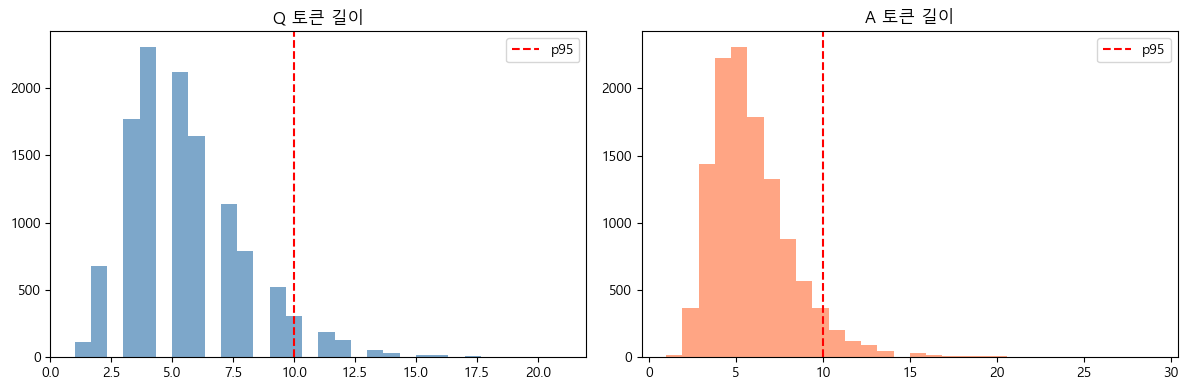

In [13]:

# Cell 3: 토큰 길이 분포 → MAX_LEN 결정

import numpy as np

q_token_lens = [len(sp.encode_as_ids(q)) for q in df['Q']]
a_token_lens = [len(sp.encode_as_ids(a)) for a in df['A']]

print("Q 토큰 길이:")
print(f"  mean={np.mean(q_token_lens):.1f}, max={max(q_token_lens)}, p95={np.percentile(q_token_lens,95):.0f}, p99={np.percentile(q_token_lens,99):.0f}")
print("A 토큰 길이:")
print(f"  mean={np.mean(a_token_lens):.1f}, max={max(a_token_lens)}, p95={np.percentile(a_token_lens,95):.0f}, p99={np.percentile(a_token_lens,99):.0f}")

# A에는 SOS/EOS 추가될 거니까 +2 고려
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(q_token_lens, bins=30, color='steelblue', alpha=0.7)
axes[0].axvline(np.percentile(q_token_lens,95), color='red', linestyle='--', label='p95')
axes[0].set_title('Q 토큰 길이')
axes[0].legend()
axes[1].hist(a_token_lens, bins=30, color='coral', alpha=0.7)
axes[1].axvline(np.percentile(a_token_lens,95), color='red', linestyle='--', label='p95')
axes[1].set_title('A 토큰 길이')
axes[1].legend()
plt.tight_layout()
plt.show()

### 데이터 파이프라인 

[SOS] 외로워 [SEP] 제가 있잖아요 [EOS] [PAD] [PAD] ... 
전체적인 흐름은 아마 이렇게 될 것이다. 한번의 시퀀스 동안 Q영역과 A영역에 대한 구분을 만들어야 했다. 
왜냐하면 디코더 전용모델이 될 것이기 때문에 기본적으로 자기회귀적인 텍스트 생서을 해야하기 때문이었다 (자기회귀적 텍스트 생성이 챗봇 task의 본질이고, 이를 위한 가장 효율적인 구조가 decoder-only)
[SEP]이후로 모델이 답하는 구조가 되는것. 

하지만 그렇다고 마냥 질문&대답 구조로 학습을 시키면 모델은 질문에 대한 답을 내놓는 계산기가 되어버릴 것이었다. 
모델학습은 결국 모델이 모르는 질문에 대해 답을 할 수 있어야 된다고 생각하기 때문에 학습 시에는 모델에게 Q영역은 마스킹해 가린다. 
이는 (ignore_index=-100) 이 코드를 사용해 Q부분을 제외해 버림 

input_ids  = seq[:-1] 자기지도 학습이 어떻게 되는지 보여주는 코드
원본 시퀀스를 2개로 복사하고 한쪽을 한칸 밀면 자연스럽게 자기지도 학습을 위한 문제와 답이 만들어진다. 



In [14]:

# Cell 4: 데이터 파이프라인 

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np

MAX_LEN = 64
IGNORE_INDEX = -100   # PyTorch CrossEntropyLoss의 표준 ignore 값

def build_sample(q, a):

    q_ids = sp.encode_as_ids(q)
    a_ids = sp.encode_as_ids(a)
    
    seq = [SOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
    
    # MAX_LEN 자르기
    if len(seq) > MAX_LEN:
        seq = seq[:MAX_LEN-1] + [EOS_ID]   # 잘려도 EOS 보장
    
    # 어디서부터 A 부분인지 위치 계산 (loss masking용)
    # [SOS] Q1 Q2 ... Qn [SEP] A1 A2 ...
    #  0    1  2     n   n+1  n+2 ...
    sep_pos = 1 + len(q_ids)   
    a_start = sep_pos + 1      
    
    # Padding
    pad_len = MAX_LEN - len(seq)
    seq = seq + [PAD_ID] * pad_len
    
    # input/target 만들기 (한 칸 shift)
    input_ids  = seq[:-1]   # 길이 MAX_LEN-1
    target_ids = seq[1:]    # 길이 MAX_LEN-1
    
    # label mask: A 부분만 학습
    # target_ids[i]가 A 토큰이거나 EOS면 그대로, 아니면 -100
    labels = []
    for i, tok in enumerate(target_ids):
        original_pos = i + 1
        if original_pos >= a_start and tok != PAD_ID:
            labels.append(tok)
        else:
            labels.append(IGNORE_INDEX)
    
    return input_ids, labels

# 전체 데이터 변환
all_inputs = []
all_labels = []
for q, a in zip(df['Q'], df['A']):
    inp, lab = build_sample(q, a)
    all_inputs.append(inp)
    all_labels.append(lab)

input_tensor = torch.tensor(all_inputs, dtype=torch.long)
label_tensor = torch.tensor(all_labels, dtype=torch.long)

print(f"input shape: {input_tensor.shape}")
print(f"label shape: {label_tensor.shape}")

# 첫 샘플 시각적으로 확인
print(f"\n=== 첫 샘플 검증 ===")
print(f"Q: {df['Q'].iloc[0]}")
print(f"A: {df['A'].iloc[0]}")
print(f"\ninput tokens: {sp.decode_ids([t for t in all_inputs[0] if t != PAD_ID])}")
print(f"\ninput ids  (앞 15개): {all_inputs[0][:15]}")
print(f"label ids  (앞 15개): {all_labels[0][:15]}")
print(f"※ label에서 -100인 자리 = loss 계산 안 함 (Q+SEP 영역)")

# Train/Valid split
dataset = TensorDataset(input_tensor, label_tensor)
n_train = int(len(dataset) * 0.9)
n_valid = len(dataset) - n_train
train_ds, valid_ds = random_split(
    dataset, [n_train, n_valid],
    generator=torch.Generator().manual_seed(42)
)
print(f"\nTrain: {len(train_ds)}, Valid: {len(valid_ds)}")

# DataLoader
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

inp_batch, lab_batch = next(iter(train_loader))
print(f"Batch — input: {inp_batch.shape}, label: {lab_batch.shape}")

input shape: torch.Size([11823, 63])
label shape: torch.Size([11823, 63])

=== 첫 샘플 검증 ===
Q: 12시 땡!
A: 하루가 또 가네요.

input tokens: 12시 땡![SEP] 하루가 또 가네요.

input ids  (앞 15개): [1, 5567, 6801, 3207, 6910, 4, 4489, 212, 5937, 6760, 2, 0, 0, 0, 0]
label ids  (앞 15개): [-100, -100, -100, -100, -100, 4489, 212, 5937, 6760, 2, -100, -100, -100, -100, -100]
※ label에서 -100인 자리 = loss 계산 안 함 (Q+SEP 영역)

Train: 10640, Valid: 1183
Batch — input: torch.Size([64, 63]), label: torch.Size([64, 63])


### RoPE 

생각보다 훨씬 어려웠음 
학습이 필요없고 간단한 코드로 구현될줄 알았지만 그게 아니었음... 훨씬 복잡한 코드와 함께 계산, 그리고 이론이 들어가 있었다. 
우선 간단히 내가 이해한 내용을 한줄로 정리하자면 이렇다. 

RoPE는 벡터의 위치만큼을 회전시켜 그 차이만큼을 계산해 위치정보를 가지게 한다. 
만약 a와b가 있다면 그걸 가상의 한 점에서 각도만큼의 차이를 통해 거리를 계산할 수 있지 않을까 하는 방식이지 않을까? 그리고 이걸 내적으로 표현하는 것이고 말이다. 
이는 아마도 초기에 있었던 더하기가 충분한 거리까지 주파수를 보존하지 못했던 것을 보완하기 위해서가 아니었을까 생각한다. 

RopE역시 초기의 위치 인코딩처럼 삼각함수를 쓴다. 아마 그렇기 때문에 학습이 필요없다는 장점이 있을지도 모르겠다. 
register_buffer라는 학습되지는 않지만 모델에 속한 텐서값을 가진다. 

rotate_half부분이 이 구조의 핵심인데 라마3의 ROPE구조를 차용해 여기서는 절반을 나눠 각각의 회전을 구한다. 
여기서 선형대수가 들어가는 것 같은데 행렬을 직교변환을 한다고 함. 코사인, 사인을 이용해 행렬을 뒤집을 수가 있음 
행렬 변환을 통해 조금이나마 선형변환이 뭔지에 대해서도 배운것 같았다. 결국 선형변환이라는 건 이런 행렬의 배열을 바꾸면서 그 레이어에서의 토큰이 가지는 좌표를 바꾸는 작업이 아니었을까. 
그리고 여기에 비선형성을 추가하면서 다음 레이어에 변환된 좌표를 사영하는 것이다. 공통 차원이 같은 이유도 설명이 되는것 같다. 
나아가 QK에서만 위치 정보를 적용 하는건 결국 V는 원본정보이기 때문에 굳이 위치정보를 가질 필요가 없기 때문이지 않을까. 
이미 중요한 정보들은 맥락과 함께 QK에서 계산이 끝났으니 V는 여기서 잃어버린 Q의 원래정보를 가중합 해줘야 하는 것일테고

RoPE: 각 위치의 Q와 K를 위치 m만큼 회전. 회전(직교변환)으로 토큰의 의미 정보는 보존하며 위치 정보만 주입. Q·K 내적이 자연스럽게 *상대 위치 차이 (m-n)*에 의존하게 됨. 학습 파라미터 0 (cos/sin은 register_buffer로 캐싱)

In [15]:
# Cell 5: Rotary Positional Embedding (RoPE)

import torch
import torch.nn as nn

class RotaryEmbedding(nn.Module):
    def __init__(self, head_dim, max_seq_len, base=10000):
        super().__init__()
        assert head_dim % 2 == 0, "head_dim must be even"
        
        # 1) 페어별 주파수: θ_i = base^(-2i/d), i=0..d/2-1
        #    shape: (head_dim/2,)
        
        inv_freq = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
        
        # 2) 각 위치 m의 회전각: m * θ_i
        #    positions (L,) ⊗ inv_freq (d/2,) → angles (L, d/2)
        positions = torch.arange(max_seq_len).float()
        angles = torch.outer(positions, inv_freq)
        
        # 3) LLaMA 스타일: 같은 angle을 두 번 복제 
        #    (L, d/2) → (L, d)

        angles = torch.cat([angles, angles], dim=-1)
        
        # 4) cos, sin 캐싱 (buffer = 학습 안 됨, 모델 저장 시 함께 저장)
        self.register_buffer('cos_cached', angles.cos(), persistent=False)
        self.register_buffer('sin_cached', angles.sin(), persistent=False)
    
    def forward(self, seq_len):
        return self.cos_cached[:seq_len], self.sin_cached[:seq_len]


def rotate_half(x):
    half = x.shape[-1] // 2
    x1 = x[..., :half]
    x2 = x[..., half:]
    return torch.cat([-x2, x1], dim=-1)


def apply_rope(x, cos, sin):
    # broadcasting: (L,D) → (1,1,L,D)
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)
    return x * cos + rotate_half(x) * sin


# ====== 동작 검증 ======
HEAD_DIM = 32
MAX_SEQ = 64

rope = RotaryEmbedding(head_dim=HEAD_DIM, max_seq_len=MAX_SEQ)
print(f"cos shape: {rope.cos_cached.shape}, sin shape: {rope.sin_cached.shape}")

# 가짜 Q로 테스트
B, num_heads, L = 2, 8, 10
fake_q = torch.randn(B, num_heads, L, HEAD_DIM)
cos, sin = rope(L)
q_rotated = apply_rope(fake_q, cos, sin)

print(f"\n입력 shape: {fake_q.shape}")
print(f"회전 후 shape: {q_rotated.shape}")

# Sanity check 1: norm 보존 (회전은 orthogonal 변환)
print(f"\n[Sanity Check 1] Norm 보존 확인 (RoPE는 회전이라 norm 변화 X)")
print(f"  원본 pos 0 norm:   {fake_q[0,0,0].norm():.4f}")
print(f"  회전 후 pos 0 norm: {q_rotated[0,0,0].norm():.4f}")
print(f"  원본 pos 9 norm:   {fake_q[0,0,9].norm():.4f}")
print(f"  회전 후 pos 9 norm: {q_rotated[0,0,9].norm():.4f}")

# Sanity check 2: 위치 0은 회전 없음 (각도 0)
print(f"\n[Sanity Check 2] pos 0은 회전각 0이라 원본과 같아야 함")
print(f"  diff at pos 0: {(fake_q[0,0,0] - q_rotated[0,0,0]).abs().max():.6f}")
print(f"  diff at pos 5: {(fake_q[0,0,5] - q_rotated[0,0,5]).abs().max():.6f}  (다름)")

cos shape: torch.Size([64, 32]), sin shape: torch.Size([64, 32])

입력 shape: torch.Size([2, 8, 10, 32])
회전 후 shape: torch.Size([2, 8, 10, 32])

[Sanity Check 1] Norm 보존 확인 (RoPE는 회전이라 norm 변화 X)
  원본 pos 0 norm:   5.2096
  회전 후 pos 0 norm: 5.2096
  원본 pos 9 norm:   5.7077
  회전 후 pos 9 norm: 5.7077

[Sanity Check 2] pos 0은 회전각 0이라 원본과 같아야 함
  diff at pos 0: 0.000000
  diff at pos 5: 1.606169  (다름)


### 어텐션 마스크 만들기 

어텐션 마스크는 어텐션 구현보다는 외부구조이기 때문에 어텐션 구조를 만들기 전, 우선적으로 어텐션 마스크를 만들어줌 

두 종류의 마스크를 한 텐서에 합친다. 
1. 인과 마스크 
2. 패딩 마스크 

torch.tril(torch.ones(L, L))

인과 마스크는 미래 시점의 토큰을 못 보게 함. 
자기회귀 생성과 학습을 위해서 마스크를 만들어 주는데 이 때 모양은 대각선 포함 아래쪽만 1, 대각선 위쪽은 0 (= 하삼각 행렬) 

(input_ids != pad_id).float()

패딩 마스크는 진짜 토큰만 보여주는 용도다,토큰이라면 1 패딩이라면0, 
이렇게 패딩된 토큰은 보지못하게 차단하고 나중에 이 둘의 마스크를 AND로 결합한다. 
곱하기를 하면 한쪽만 0이어도 0으로 되기 때문이다. 

시각화를 통해서 패딩이 어떻게 처리되는지 토큰5+패딩5개로 확인해볼수도 있었다. 

마스크는 데이터 파이프라인의 시프트와 연결된다. 
시프트는 인풋/답을 한칸 어긋나게 만들어 각 입력에 대한 답을 만들고 여기에 마스크를 씌워 미래 정답을 보지 못하게 만듬 
패딩 값이 Q값을 들어가지만 패딩의 위치 라벨을 -100으로 잡아서 계산에서는 무시됨 어텐션 마스크는 별개로 점수에 -inf를 채워 결과를 0으로 만든다. 




In [16]:
# Cell 6: Attention Mask 만들기

import torch

def make_attention_mask(input_ids, pad_id=PAD_ID):
   
    B, L = input_ids.shape
    device = input_ids.device
    
    # 1 Causal mask: (L, L) 하삼각 (대각선 포함)
    #    row i에서 column j>i 자리는 0 → 미래 못 봄
    causal = torch.tril(torch.ones(L, L, device=device))  # (L, L)
    
    # 2 Padding mask: key 쪽 PAD를 차단
    #    (B, L) → (B, 1, L) → broadcasting으로 (B, L, L)에 적용
    pad = (input_ids != pad_id).float()  
    pad = pad.unsqueeze(1)               
    
    # 3 AND 결합 
    mask = causal.unsqueeze(0) * pad     
    
    # 4 num_heads 차원 추가 
    mask = mask.unsqueeze(1)            
    
    return mask


# 동작 검증 

# 가짜 입력: 첫 샘플 (앞 5개 토큰 + PAD 5개)
test_ids = torch.tensor([
    [1, 5567, 6801, 3207, 4,    0, 0, 0, 0, 0],   
    [1, 4489, 212, 5937, 6760,  2, 0, 0, 0, 0],  
])

mask = make_attention_mask(test_ids)
print(f"Mask shape: {mask.shape}")   # (2, 1, 10, 10) 이 나아야함 

# 시각화 

print(f"\n샘플 0 mask (1=attend, 0=차단):")
print(f"실제 토큰 5개 + PAD 5개")
print(mask[0, 0].int().numpy())

Mask shape: torch.Size([2, 1, 10, 10])

샘플 0 mask (1=attend, 0=차단):
실제 토큰 5개 + PAD 5개
[[1 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0]
 [1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]]


### 멀티헤드 어텐션 

Attention(Q, K, V) = softmax(QKᵀ / √d_k) · V
1. QK와의 유사도 = QKᵀ 
2. 스케일링 =  /√d_k
3. 마스크 = -inf
4. 정규화 = 소프트맥스
5. 가중합 = · V  

QKV는 각 QKV의 목적에 맞는 좌표계를 가진다. 
그렇기 때문에 같은 x에서 만들어지고 이 값은 3개의 선형 투영을 통해 변환된다. 
하지만 어텐션은 한가지의 관계밖에 볼수 없다 마치 CNN의 필터처럼 그래서 어텐션 역시 여러개의 해드를 가지게 된다. 이게 멀티헤드 어텐션이다. 
스케일링을 해 주는 이유는 Q·Kᵀ 값들의 분산이 head_dim에 비례해서 커지기 때문이다. 그대로 소프트맥스를 통과하면 값들이 마치 원핫 인코딩처럼 될 가능성이 높기 때문에 √d_k로 나눠 분산을 1로 유지해서 작은 값들도 의미를 가지게 해준다. 

out.transpose(1, 2).contiguous().view(B, L, D)  
파이토치 텐서는 메모리에 연속된 블록으로 저장되ㅗ는데 트랜스포스는 메모리는 그대로 둠
view는 연속성을 요구하기 때문에 트랜스포스 후 바로 view를 쓰면 오류가 생김 contiguous()를 통해 복사를 해줘야 한다. 
이런 복잡한 방식 말고도 .reshape도 사용가능하다. 

Output projection 
8개 헤드의 결과를 연결해서 하나의 벡터로 만든 뒤 한번 더 레이어를 통과한다. 
헤드를 연결하지 않으면 독립채널이 되어버리기 때문임 

Q와 K가 같은 좌표계를 공유해야 내적이 의미 있는 비교가 됨. 그래서 wq, wk가 함께 학습. V는 비교에 안 쓰이므로 자유로운 좌표계 


In [17]:
# Cell 7: Multi-Head Attention

import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, f"d_model({d_model}) must be divisible by num_heads({num_heads})"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5  
        
        # Q, K, V, Output projection (현대 LLM은 보통 bias=False)
        self.wq = nn.Linear(d_model, d_model, bias=False)
        self.wk = nn.Linear(d_model, d_model, bias=False)
        self.wv = nn.Linear(d_model, d_model, bias=False)
        self.wo = nn.Linear(d_model, d_model, bias=False)
        
        self.attn_dropout = nn.Dropout(dropout)
    
    def forward(self, x, mask, cos, sin):

        B, L, D = x.shape
        H, Hd = self.num_heads, self.head_dim
        
        # 1) Linear projection
        q = self.wq(x)   
        k = self.wk(x)
        v = self.wv(x)
        
        # 2) Head 분할
        q = q.view(B, L, H, Hd).transpose(1, 2)   
        k = k.view(B, L, H, Hd).transpose(1, 2)
        v = v.view(B, L, H, Hd).transpose(1, 2)
        
        # 3) RoPE: Q, K만 회전
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)
        
        # 4) Scaled dot-product
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        
        # 5) Mask 적용
        scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # 6) Softmax
        attn = F.softmax(scores, dim=-1)   
        attn = self.attn_dropout(attn)
        
        # 7) V 가중합
        out = torch.matmul(attn, v)
        
        # 8) Head 합치기
        out = out.transpose(1, 2).contiguous().view(B, L, D)
        
        # 9) Output projection
        out = self.wo(out)
        
        return out


# ====== 동작 검증 ======
torch.manual_seed(42)

D_MODEL = 256
NUM_HEADS = 8
HEAD_DIM = D_MODEL // NUM_HEADS  # 32

mha = MultiHeadAttention(d_model=D_MODEL, num_heads=NUM_HEADS, dropout=0.1)
rope = RotaryEmbedding(head_dim=HEAD_DIM, max_seq_len=MAX_LEN)

# 가짜 입력
B, L = 2, 10
x = torch.randn(B, L, D_MODEL)
test_ids = torch.tensor([
    [1, 5567, 6801, 3207, 4,    0, 0, 0, 0, 0],
    [1, 4489, 212, 5937, 6760,  2, 0, 0, 0, 0],
])
mask = make_attention_mask(test_ids)
cos, sin = rope(L)

out = mha(x, mask, cos, sin)

print(f"입력 shape: {x.shape}")
print(f"출력 shape: {out.shape}")
print(f"NaN 체크: {torch.isnan(out).any().item()}")
print(f"Inf 체크: {torch.isinf(out).any().item()}")
print(f"파라미터 수: {sum(p.numel() for p in mha.parameters()):,}")

# 파라미터 검증: Wq, Wk, Wv, Wo 각 256×256
expected_params = 4 * (D_MODEL * D_MODEL)
print(f"예상 파라미터: {expected_params:,}  (4개 Linear × 256×256)")

입력 shape: torch.Size([2, 10, 256])
출력 shape: torch.Size([2, 10, 256])
NaN 체크: False
Inf 체크: False
파라미터 수: 262,144
예상 파라미터: 262,144  (4개 Linear × 256×256)


### 전체 모델 조립 

지금까지 만들어둔 부품을 조립해 모델을 만들게 된다. 
모델의 대부분의 연산은 FFN에서 이뤄진다. 어텐션만 있으면 토큰간의 정보교환만 일어나게 되기 때문에 각 토큰을 넓은 차원에 펼쳐 정리할 시간이 필요하다. 이것이 FFN에서 일어나는 차원 확장,활성화 함수, 게이팅, 차원축소, 잔차연결이 하는 전체적인 일이다. 

Pre-LN 
        x = x + self.dropout1(self.attn(self.norm1(x), mask, cos, sin))
x를 우선 정규화 하고 어텐션+FFN을 통과한다. 그리고 드롭아웃 후 원본에 x를 더하는 잔차연결
중요한 차이점은 정규화를 우선적으로 해준다는 점이다 그래서 Pre LN, 학습 안정성이 올라가기 때문에 요새는 정규화를 먼저 해주는 쪽으로 바뀌었다고 한다. 

잔차연결 x = x +f(x) 
매 레이어마다 넓은 의미의 정보손실이 일어나지 않게 원본 정보를 계속해서 더해주는 행위를 말한다. 
트랜스포머 이전에는 매 레이어마다는 하지 않는것 같았지만 이제는 매 레이어마다 해주는것 같음 
그리고 이건 첫레이어부터 이뤄지는 경우가 많아진것 같았다. 

Tied Embedding 
self.lm_head.weight = self.tok_embed.weight

간단히 정리하자면 입력이 출력과 같다는 것 토큰ID > 벡터 > 토큰ID 확률로
결국 이는 입력과 출력의 임베딩 가중치를 공유. 같은 vocab을 다루니까. 파라미터 절약.


Final Norm — Pre-LN 모델의 필수 후처리

pre LN은 매 레이어 앞에서 정규화를 하기 때문에 마지막 블록에서의 정규화는 되지 않는 문제점이 있다. 
그래서 이 때는 마지막으로 정규화를 해주면서 정리를 해줌 후로는 소프트맥스를 거쳐 각 토큰마다의 확률을 통해 모델 전략을 통해 적절한 토큰을 생성한다. 

```
input_ids (B, L)
    ↓
tok_embed → (B, L, d_model=256)
    ↓
embed_dropout
    ↓
┌─────────────────────────────────────────┐
│ Block 1:                                 │
│   x + dropout(MHA(norm1(x), mask, RoPE))│
│   x + dropout(FFN(norm2(x)))             │
└─────────────────────────────────────────┘
    ↓
Block 2 (동일 구조)
    ↓
Block 3 (동일 구조)
    ↓
final_norm
    ↓
lm_head (tied with tok_embed) → (B, L, vocab_size=8000)
    ↓
softmax → 다음 토큰 확률
```



In [18]:
# Cell 8: FeedForward + DecoderBlock + 전체 모델

class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.w2(self.dropout(F.relu(self.w1(x))))


class DecoderBlock(nn.Module):

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.dropout1 = nn.Dropout(dropout)
        
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    def forward(self, x, mask, cos, sin):
        # Pre-LN: 정규화 → sublayer → residual
        x = x + self.dropout1(self.attn(self.norm1(x), mask, cos, sin))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x


class TransformerChatbot(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff,
                 max_seq_len, dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        
        # Embedding (RoPE 쓰니까 positional embedding은 없음)
        self.tok_embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.embed_dropout = nn.Dropout(dropout)
        
        # RoPE (모든 layer가 공유)
        head_dim = d_model // num_heads
        self.rope = RotaryEmbedding(head_dim, max_seq_len)
        
        # Decoder blocks
        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # 최종 LayerNorm (Pre-LN 모델은 마지막에 norm 한 번 더 필요)
        self.final_norm = nn.LayerNorm(d_model)
        
        # LM Head: d_model → vocab_size
        # Tied embedding: tok_embed.weight를 LM head가 공유
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_embed.weight   # 가중치 공유
        
        # 초기화
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, input_ids):
        B, L = input_ids.shape
        
        # 1) Mask 만들기
        mask = make_attention_mask(input_ids, pad_id=self.pad_id)
        
        # 2) Embedding
        x = self.tok_embed(input_ids)             
        x = self.embed_dropout(x)
        
        # 3) RoPE 테이블 가져오기
        cos, sin = self.rope(L)
        
        # 4) Decoder blocks 통과
        for block in self.blocks:
            x = block(x, mask, cos, sin)
        
        # 5) 최종 norm
        x = self.final_norm(x)
        
        # 6) LM head
        logits = self.lm_head(x)                 
        
        return logits


# ====== 모델 생성 ======
VOCAB_SIZE = sp.get_piece_size()   # 8000
D_MODEL = 256
NUM_HEADS = 8
NUM_LAYERS = 3
D_FF = 1024
DROPOUT = 0.1

model = TransformerChatbot(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_seq_len=MAX_LEN,
    dropout=DROPOUT,
    pad_id=PAD_ID,
)

# 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터: {total_params:,}")
print(f"학습 가능 파라미터: {trainable_params:,}")

# 파라미터 구성 breakdown
emb_params = sum(p.numel() for p in model.tok_embed.parameters())
block_params = sum(p.numel() for p in model.blocks.parameters())
head_params = sum(p.numel() for p in model.lm_head.parameters())
print(f"\nBreakdown:")
print(f"  Embedding: {emb_params:,}  (tied with LM head)")
print(f"  Decoder blocks ({NUM_LAYERS}개): {block_params:,}")
print(f"  LM head: {head_params:,}  ← Embedding과 weight 공유")
print(f"  실제 LM head 추가: 0 (tied)")

# Forward 동작 확인
sample_input = torch.tensor([
    [1, 5567, 6801, 3207, 4, 4489, 212, 5937, 6760, 2, 0, 0, 0, 0, 0],
    [1, 4489, 212, 5937, 6760, 4, 5567, 6801, 3207, 6910, 2, 0, 0, 0, 0],
])

model.eval()
with torch.no_grad():
    logits = model(sample_input)

print(f"\n입력 shape: {sample_input.shape}")
print(f"출력 logits shape: {logits.shape}")
print(f"NaN: {torch.isnan(logits).any().item()}, Inf: {torch.isinf(logits).any().item()}")
print(f"logits 통계: mean={logits.mean():.3f}, std={logits.std():.3f}")

전체 파라미터: 4,414,720
학습 가능 파라미터: 4,414,720

Breakdown:
  Embedding: 2,048,000  (tied with LM head)
  Decoder blocks (3개): 2,366,208
  LM head: 2,048,000  ← Embedding과 weight 공유
  실제 LM head 추가: 0 (tied)

입력 shape: torch.Size([2, 15])
출력 logits shape: torch.Size([2, 15, 8000])
NaN: False, Inf: False
logits 통계: mean=-0.004, std=0.250


### 학습 루프 

우선 옵티마이저로는 AdamW를 사용한다. 
학습 스케줄러는 웜업 + 코사인 스케줄러를 사용한다. 
에폭은 20 Label Smoothing을 통해서 각 라벨링된 답이 1이 되지 않도록 만들어준다. 모델에게 이 답의  확신도를 낮추는 방법 
Gradient Clipping은 기울기가 가끔 엄청나게 커질 때 방향만 유지한 채로 크기는 잘라주는 방식이다. GRAD_CLIP
model.train(), model.eval() 이 두개는 각 모델의 학습, 추론 모드를 담당한다. 



### 학습 결과 

모델 학습에서 신호는 두개를 참고했다. 
하나는 기본적인 로스율, 그리고 PPL이라는 수치다 
ppl이라는 수치가 조금 생소했는데, 모델이 다음 토큰을 몇개의 후보로 좁혔는가? 라는 의미다 
만약 ppl이 1이라면 다음 토큰을 완벽하게 예측한 것이고 100 이라면 100개중 하나의 후보를 선택한 것이 된다. 
이번 학습에서는 모델이 일괄적으로 학습 데이터와 검증용 데이터에서 큰 차이를 보여줬다. 아래 추가로 시각화 한것을 통해서 
해당 모델이 과적합이 되었다는 판단을 내렸다. 

### 하이퍼 파라미터 
에폭 - 20 
배치 사이즈 - 64 로컬 개인용 노트북으로 충분하다 판단했음 
weight decay - 0.01 약한 L2정규화 과적합을 잡아주기 위해서였음 
warmup ratio - 0.1 전체 스텝의 10% pre LN이라 굳이 필요는 없었지만 안전장치로 
Gradient clip - 1.0 기울기 폭발을 방지 
Label smoothing - 0.1 확신도를 완화, 과적합을 방지 
Dropout - 0.1 역시 과적합을 방지 



In [ ]:

# Cell 9: Training Loop

import math, time
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

model = model.to(device)

# Hyperparams
EPOCHS = 20
LR = 5e-4
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
GRAD_CLIP = 1.0
LABEL_SMOOTHING = 0.1

# Optimizer (AdamW, betas는 현대 LLM 표준)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))

# Loss (ignore -100, label smoothing)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, label_smoothing=LABEL_SMOOTHING)

# Scheduler: warmup → cosine decay
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

print(f"Total steps: {total_steps}, Warmup: {warmup_steps}")

# ====== Train / Validate 함수 ======
def train_one_epoch(model, loader):
    model.train()
    total_loss, total_tokens = 0, 0
    
    for input_ids, labels in loader:
        input_ids, labels = input_ids.to(device), labels.to(device)
        
        logits = model(input_ids)  
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        
        # token-weighted average를 위한 누적
        n = (labels != IGNORE_INDEX).sum().item()
        total_loss += loss.item() * n
        total_tokens += n
    
    return total_loss / total_tokens

@torch.no_grad()
def validate(model, loader):
    model.eval()
    total_loss, total_tokens = 0, 0
    for input_ids, labels in loader:
        input_ids, labels = input_ids.to(device), labels.to(device)
        logits = model(input_ids)
        loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
        n = (labels != IGNORE_INDEX).sum().item()
        total_loss += loss.item() * n
        total_tokens += n
    return total_loss / total_tokens

# ====== Main Loop ======
history = {'train_loss': [], 'valid_loss': [], 'train_ppl': [], 'valid_ppl': []}
best_valid_loss = float('inf')

print("\n학습 시작...")
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader)
    valid_loss = validate(model, valid_loader)
    elapsed = time.time() - t0
    
    train_ppl = math.exp(train_loss)
    valid_ppl = math.exp(valid_loss)
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_ppl'].append(train_ppl)
    history['valid_ppl'].append(valid_ppl)
    
    is_best = ''
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'best_model.pt')
        is_best = ' ★'
    
    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train ppl={train_ppl:6.2f} | valid ppl={valid_ppl:6.2f} | "
          f"lr={lr_now:.2e} | {elapsed:.1f}s{is_best}")

print(f"\n최고 valid loss: {best_valid_loss:.4f} (ppl={math.exp(best_valid_loss):.2f})")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Total steps: 3340, Warmup: 334

학습 시작...
Epoch  1/20 | train ppl=2056.92 | valid ppl=575.53 | lr=2.50e-04 | 6.6s ★
Epoch  2/20 | train ppl=413.13 | valid ppl=346.62 | lr=5.00e-04 | 5.6s ★
Epoch  3/20 | train ppl=287.33 | valid ppl=284.51 | lr=4.96e-04 | 5.2s ★
Epoch  4/20 | train ppl=219.08 | valid ppl=245.18 | lr=4.85e-04 | 5.5s ★
Epoch  5/20 | train ppl=170.10 | valid ppl=216.87 | lr=4.67e-04 | 5.3s ★
Epoch  6/20 | train ppl=132.75 | valid ppl=196.96 | lr=4.42e-04 | 5.4s ★
Epoch  7/20 | train ppl=104.05 | valid ppl=182.50 | lr=4.11e-04 | 5.6s ★
Epoch  8/20 | train ppl= 82.15 | valid ppl=171.89 | lr=3.75e-04 | 5.5s ★
Epoch  9/20 | train ppl= 66.09 | valid ppl=165.26 | lr=3.36e-04 | 5.6s ★
Epoch 10/20 | train ppl= 54.22 | valid ppl=159.23 | lr=2.93e-04 | 5.3s ★
Epoch 11/20 | train ppl= 45.33 | valid ppl=155.48 | lr=2.50e-04 | 5.5s ★
Epoch 12/20 | train ppl= 38.80 | valid ppl=152.17 | lr=2.07e-04 | 5.3s ★
Epoch 13/20 | train ppl= 33.8

학습진행을 추척할 때는 ppl을 확인했지만 시각화자료는 로스율을 기준으로 정했다. 
ppl이 좀 더 로스율 보다 명확히 차이가 보ㅗ인다고 생각하기도 했기 때문이고 loss값의 차이가 실제 수치로는 두드러지지 않았기 때문이기도 했다 

5 에폭 이후로 학습 데이터와 검증용 데이터에서 차이가 많이 두드러지는것이 특징이고 이것은 과적합의 전형적인 증상이라 판단함. 





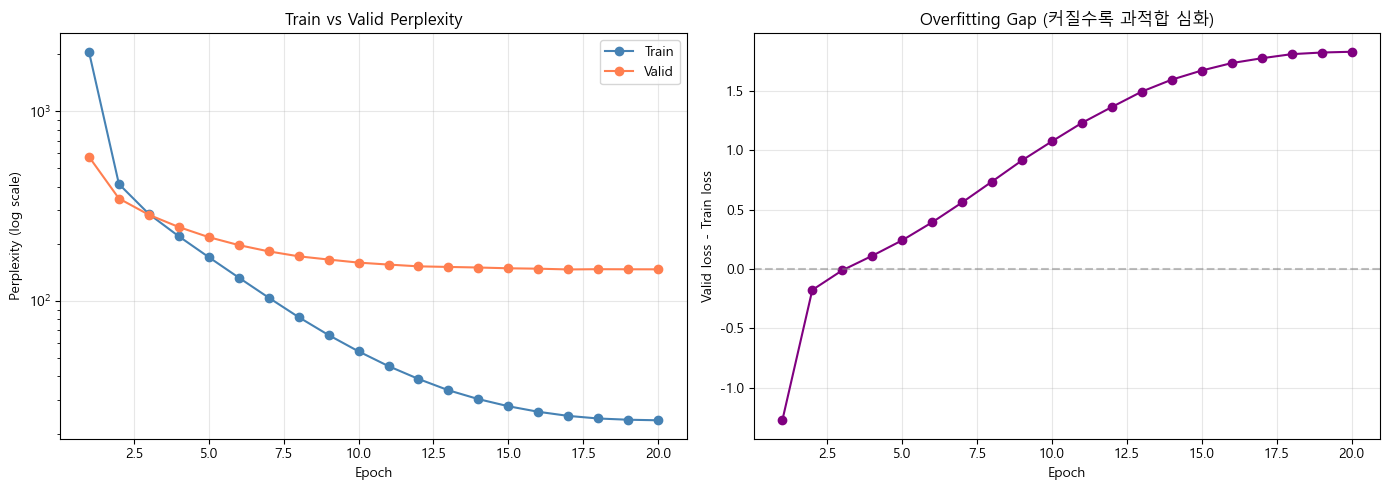

In [ ]:
# train/valid loss 곡선
import matplotlib.pyplot as plt

epochs = list(range(1, EPOCHS+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PPL (log scale)
axes[0].plot(epochs, history['train_ppl'], 'o-', label='Train', color='steelblue')
axes[0].plot(epochs, history['valid_ppl'], 'o-', label='Valid', color='coral')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perplexity (log scale)')
axes[0].set_title('Train vs Valid Perplexity')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gap (train-valid 차이)
gaps = [v - t for t, v in zip(history['train_loss'], history['valid_loss'])]
axes[1].plot(epochs, gaps, 'o-', color='purple')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Valid loss - Train loss')
axes[1].set_title('Overfitting Gap (커질수록 과적합 심화)')
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 모델을 돌려보기 

위의 데이터는 모델이 어떻게 학습을 했는지에 대한 신호에 불과하다 생각했기 때문에 추가로 모델을 돌려서 확인해보기로 했다. 
학습은 병렬이지만 추론은 순차구조라는게 조금 차이점 같은데 이는 모델이 생성을 하기 위해서는 계속해서 과거의 응답을 통해 바로 다음 토큰을 예측하기 때문이다. 

매 스텝마다 마지막 위치의 값을 확인하고 토큰 선택 전략은 2가지로 나뉘었다. 
하나는 greedy 방식과 나머지는 샘플링 방식 

그리드 방식은 말 그대로 가장 높은 확률을 선택하는 방식이지만 챗봇은 샘플링이 조금 더 자유로운 표현이 가능하다고 생각한다. 
물론 샘플링에서도 어느정도 범위를 정하기 위해서는 출력 시 온도를 통해 확률 분포를 조정할 필요가 있었다. 
사실, 그리드 방식이냐 샘플링 방식이냐는 그저 온도를 얼마나 높이냐에 따른 차이일  수도 있겠다는 생각이 들었다. 

출력 시 파라미터는 결국 3개로 나뉜다. 

온도 - 완률분포의 범위 
Top K - 상위 k개의 토큰만 고래 
TOP P - 누적확률 p까지의 토큰만 

K는 정적이지만 P는 동적이다. 

모델 생성은 두가지를 비교해서 확인했다. 하나는 그리드 방식의 출력 하나는 온도를 0.8정도로 맞춘 출력물 
결과 두개의 출력문이 차이가 많이 났다. 0.8인데도 출력이 많이 무너지는 모습에 확실히 학습이 아직 완벽하게 되지 않았다는 생각이 들었다. 


In [ ]:
# Cell 10: Generation 

# Best 모델 로드
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
print("Best model loaded.")

@torch.no_grad()
def generate(question, max_new_tokens=30, strategy='greedy', 
             temperature=1.0, top_k=None, top_p=None):
    model.eval()
    
    # 1) 입력 시퀀스 구성: [SOS] Q [SEP]
    q_ids = sp.encode_as_ids(normalize_text(question))
    input_ids = [SOS_ID] + q_ids + [SEP_ID]
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
    
    # 2) Autoregressive 생성
    generated = []
    for _ in range(max_new_tokens):
        # 현재 시퀀스로 forward
        logits = model(input_tensor)           
        next_logits = logits[0, -1, :]        
        
        # 다음 토큰 선택
        if strategy == 'greedy':
            next_id = next_logits.argmax().item()
        else:  # sampling
            next_logits = next_logits / temperature
            if top_k is not None:
                v, _ = torch.topk(next_logits, top_k)
                next_logits[next_logits < v[-1]] = float('-inf')
            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(next_logits, descending=True)
                cumprobs = F.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
                remove = cumprobs > top_p
                remove[1:] = remove[:-1].clone()
                remove[0] = False
                next_logits[sorted_idx[remove]] = float('-inf')
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
        
        # EOS면 종료
        if next_id == EOS_ID:
            break
        
        generated.append(next_id)
        # 시퀀스에 append하여 다음 step
        input_tensor = torch.cat([
            input_tensor,
            torch.tensor([[next_id]], device=device)
        ], dim=1)
        
        # MAX_LEN 안전장치
        if input_tensor.size(1) >= MAX_LEN:
            break
    
    return sp.decode_ids(generated)


def chat(question, **kwargs):
    print(f"Q: {question}")
    print(f"A: {generate(question, **kwargs)}")
    print()


# ====== 테스트 ======
print("=" * 50)
print("[Greedy Decoding]")
print("=" * 50)
# 학습 데이터에 있던 Q
chat("12시 땡!")
chat("3박4일 놀러가고 싶다")
# 학습 데이터에 없을 법한 Q
chat("오늘 너무 피곤해")
chat("뭐 먹지")
chat("주말에 뭐할까")
chat("일하기 싫다")
chat("비가 와")
chat("외로워")

print("=" * 50)
print("[Sampling, temperature=0.8, top_p=0.9]")
print("=" * 50)
for _ in range(3):
    chat("외로워", strategy='sampling', temperature=0.8, top_p=0.9)

Best model loaded.
[Greedy Decoding]
Q: 12시 땡!
A: 아름다운 변화도 좋겠죠.

Q: 3박4일 놀러가고 싶다
A: 저도요!

Q: 오늘 너무 피곤해
A: 잠시 쉬어도 돼요.

Q: 뭐 먹지
A: 맛있는 거 드세요.

Q: 주말에 뭐할까
A: 저랑 놀아요.

Q: 일하기 싫다
A: 저도요!

Q: 비가 와
A: 잠시 쉬어도 돼요.

Q: 외로워
A: 제가 있잖아요.

[Sampling, temperature=0.8, top_p=0.9]
Q: 외로워
A: 많이 해서 그래요.

Q: 외로워
A: 게 아니에요.

Q: 외로워
A: 제가 있잖아요.



### 본적없는 Q에 대해서는 얼마나 좋은 대답을 할 것인가? 

그리드 방식의 대답이 정석적이었기 때문에 추가로 모델이 모르는 문장에 대해서는 얼마나 대답이 가능할지에 대한 테스트를 진행했다. 
이유는 결국 텍스트 생성 모델은 자신이 모르는 문장에 대해서 답이 가능해야 제대로 된 학습이 되었다고 생각했기 때문이다. 
결과는 좋지 않았다. 그리드 방식에서도 모델의 답변이 무너졌기 때문이다. 그래도 다행인 점은 치킨, 피자 같은 단어를 통해 먹는다 라는 상관관계를 만들어 내지 않았나 해서 학습이 완전히 실패한 것은 아니라는 생각을 하게 되었다. 

이 부분은 몇번의 테스트를 반복해서 중요하다 싶은 특징만 정리하자면 아래와 같았다. 

학습 데이터에 유사 패턴 있는 Q: "이별했어" → "마음이 허전한가봐요" 
    → 모델의 일반화 능력이 데이터 본 도메인 안에선 작동
학습 데이터에 *희소한 단어*: "치킨"(3회) → "맛있게 드세요"  
    → SentencePiece subword가 다른 음식 단어와 정보 공유
학습 데이터에 *음식 맥락만 있는* 단어: "주식"(8회, 음식 맥락) → "맛있게 드세요" 
    → 단어가 있어도 *맥락이 한쪽*이면 다른 의미로 못 씀
학습 데이터에 *없는* 단어: "기말고사"(0회) → "주기적으로 하는 게 좋죠" 
    → 학습 안 된 단어는 처리 불가

In [ ]:
# Cell 10-b: Unseen Q 테스트 + 다양성 확인

print("=" * 50)
print("[학습 데이터에 정확히 없는 Q — Greedy]")
print("=" * 50)

unseen_qs = [
    "치킨 먹고 싶다",
    "월요일이 싫어",          
    "사장님이 또 갈궈",        
    "라면 끓이는 중",
    "주식 또 떨어졌어",
    "기말고사 망했어",        
    "이별했어",
    "고양이 키우고 싶다",
    "면접 떨어졌어",
    "결혼은 언제하지",
    "회사 그만두고 싶다",
]

for q in unseen_qs:
    chat(q)

print("\n" + "=" * 50)
print("[Sampling 다양성 — temperature 비교]")
print("=" * 50)
print("\n>>> temperature=1.0, top_p=0.9, 같은 Q 3번")
for _ in range(3):
    chat("외로워", strategy='sampling', temperature=1.0, top_p=0.9)

print(">>> temperature=1.3, top_p=0.95, 같은 Q 3번")
for _ in range(3):
    chat("외로워", strategy='sampling', temperature=1.3, top_p=0.95)

[학습 데이터에 정확히 없는 Q — Greedy]
Q: 치킨 먹고 싶다
A: 맛있게 드세요.

Q: 월요일이 싫어
A: 많은 시간이 흘렀네요.

Q: 사장님이 또 갈궈
A: 더 많이 지쳤나봐요.

Q: 라면 끓이는 중
A: 맛나게 드세요.

Q: 주식 또 떨어졌어
A: 주식으로 돈 쓰고 나가세요.

Q: 기말고사 망했어
A: 자신의 감정을 주변 사람들에게 터놓고 이야기해보세요.

Q: 이별했어
A: 많이 힘들겠어요.

Q: 고양이 키우고 싶다
A: 다 잘 될 거예요.

Q: 면접 떨어졌어
A: 회사와 자신에 대해서 더 공부해서 자신감을 가져보세요.

Q: 결혼은 언제하지
A: 자신의 감정을 주변 사람들에게 터놓고 이야기해보세요.

Q: 회사 그만두고 싶다
A: 많이 답답한가봐요.


[Sampling 다양성 — temperature 비교]

>>> temperature=1.0, top_p=0.9, 같은 Q 3번
Q: 외로워
A: 아니에요.

Q: 외로워
A: 좋은 사세요.

Q: 외로워
A: 제가죠.

>>> temperature=1.3, top_p=0.95, 같은 Q 3번
Q: 외로워
A: 조급해지면 서로의만의 해보세요 체육 거예요.공원 외국인인데으로 만들어보세요개월만에몰갑 점은 발렌타한테 선물로출하고 한 분이에요. 바라는 용기를 놓고앙처리아서

Q: 외로워
A: 많은 안 넘었네 빠를 오세요.

Q: 외로워
A: 시험 자존감 일이네요 들고 그렇겠죠춤하죠낄.뎠세요하느라상 좀공평 나아졌길 때부터 마련이죠. 대화가 퇴근세요.



### 임베딩 진단 

응답을 보면 어느정도의 상관관계가 생겼다는 판단을 내렸다. 
하지만 임베딩 차원까지의 상관관계가 아직 제대로 학습이 되지 않았나 하는 생각이 들어 그것을 확인해보기로 했다. 
우선 가장 간단한 방법은 임베딩 차원에서의 토큰들의 분포를 통해 직접 각 토큰들 끼리의 군집화가 이뤄졌는지 확인하는 것이었다. 
만약 학습이 제대로 되었다면 임베딩 공간에서의 토큰들이 어느정도 의미있는 좌표를 가지게 될 것이라고 생각했기 때문이다. 

### 특정단어의 이웃을 수치로 확인 

우선 첫번째로는 테스트 문장에서의 토큰들을 통해 이웃관계를 확인하는 일이었다. 
확인 결과 정상적으로 작동한 토큰에성의 임베딩은 이웃이 실제로 상관관계에 있는 토큰들이 많았다는 점이었다. 
하지만 일부분이라는 점이 조금 아쉬웠다. 

### 특징 

- 주식의 이웃 sim이 모두 비슷한 위치에 있었다는 점 그것도 관계없는 토큰들인 경우가 많았다. 
- 반명 사랑 의 이웃음 사람,사랑이,함께 등 명확한 의미를 가지고 있었다. 

학습된 임베딩은 특정 의미영역에서 가까워지고 나머지와는 멀어진다. 하지만 학습이 되지 않은 임베딩은 랜덤 벡터로 모든 이웃과 비슷한 거리를 가지는데 이는 아마 주식이라는 임베딩 벡터값이 아직 학습되지 않은 증거가 아닐까? 



In [ ]:
# Cell 11: 임베딩 공간 진단

%pip install scikit-learn -q

import torch.nn.functional as F
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# 1) 임베딩 가져오기 (학습된 weight)
embeddings = model.tok_embed.weight.detach().cpu() 
print(f"Embedding shape: {embeddings.shape}")

# 2) 토큰 빈도 계산 (자주 나오는 토큰 우선 분석)
from collections import Counter
counter = Counter()
for q, a in zip(df['Q'], df['A']):
    counter.update(sp.encode_as_ids(q))
    counter.update(sp.encode_as_ids(a))

# Special token 제외, 빈도 top 200
specials = {PAD_ID, SOS_ID, EOS_ID, UNK_ID, SEP_ID}
top_ids = [tid for tid, _ in counter.most_common(300) if tid not in specials][:200]
print(f"분석 대상: 빈도 top {len(top_ids)} 토큰")

# 3) 특정 단어들의 nearest neighbor 분석
def nearest_neighbors(word, k=8):
    """단어를 토큰화해서 첫 토큰의 임베딩으로 NN 찾기"""
    pieces = sp.encode_as_pieces(word)
    ids = sp.encode_as_ids(word)
    if len(ids) == 0:
        print(f"'{word}': 토큰화 실패")
        return
    
    # 첫 subword 토큰의 임베딩 (의미를 가장 많이 담음)
    target_id = ids[0]
    target_piece = pieces[0]
    target_emb = embeddings[target_id].unsqueeze(0)   
    
    # 모든 토큰과 cosine similarity
    sims = F.cosine_similarity(target_emb, embeddings, dim=-1)
    
    # 자기 자신 + special token 제외
    for sid in [target_id] + list(specials):
        sims[sid] = -1
    
    top_k = sims.topk(k)
    
    print(f"\n'{word}' (토큰: {pieces}, 첫 토큰 '{target_piece}' 기준)")
    for sim, idx in zip(top_k.values, top_k.indices):
        piece = sp.id_to_piece(idx.item())
        print(f"  {piece:<15} sim={sim.item():.3f}")

# 짚어볼 단어들
print("=" * 60)
print("[가설 1 검증: 의미적 이웃이 맞는가]")
print("=" * 60)

# 미스가 났던 단어들
for word in ["주식", "사장", "기말고사", "결혼"]:
    nearest_neighbors(word)

print("\n" + "=" * 60)
print("[정상 작동 단어들 비교]")
print("=" * 60)
for word in ["외로", "사랑", "치킨", "여행"]:
    nearest_neighbors(word)


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Embedding shape: torch.Size([8000, 256])
분석 대상: 빈도 top 200 토큰
[가설 1 검증: 의미적 이웃이 맞는가]

'주식' (토큰: ['▁주식'], 첫 토큰 '▁주식' 기준)
  ▁오디션            sim=0.833
  땅               sim=0.832
  륜               sim=0.831
  뻤               sim=0.827
  ▁어찌해야           sim=0.825
  ▁괜              sim=0.821
  ▁허리가            sim=0.821
  ▁쫄              sim=0.819

'사장' (토큰: ['▁사', '장'], 첫 토큰 '▁사' 기준)
  ▁가              sim=0.289
  ▁챙겨             sim=0.267
  ▁들              sim=0.244
  ▁가보세요           sim=0.238
  ▁식              sim=0.221
  ▁준비             sim=0.220
  ▁날              sim=0.220
  ▁생각             sim=0.218

'기말고사' (토큰: ['▁기', '말고', '사'], 첫 토큰 '▁기' 기준)
  ▁아파             sim=0.272
  ▁몸              sim=0.267
  ▁바라             sim=0.249
  ▁소              sim=0.247
  ▁쉬              sim=0.246
  ▁조심하세요          sim=0.235
  ▁식              sim=0.235
  ▁성              sim=0.233

'결혼' (토큰: ['▁결혼'], 첫 토큰 '▁결혼' 기준)
  ▁진정한            sim=0

### 임베딩 차원 시각화 

임베딩 차원에서의 토큰 분포를 좌표로 확인해 보기도했다. 
여기서의 가설은 임베딩 학습이 제대로 되었다면 의미있는 분포를 가지리라 생각했기 때문이었다. 
같은 의미영역이 같은 모양으로 어느정도는 묶인것을 확인 할수는 있었다. 물론 완벽한건 아닌것 같다. 
아마 전체적으로는 중앙으로 모여있기 때문이었을까? 


t-SNE 계산 중...
완료


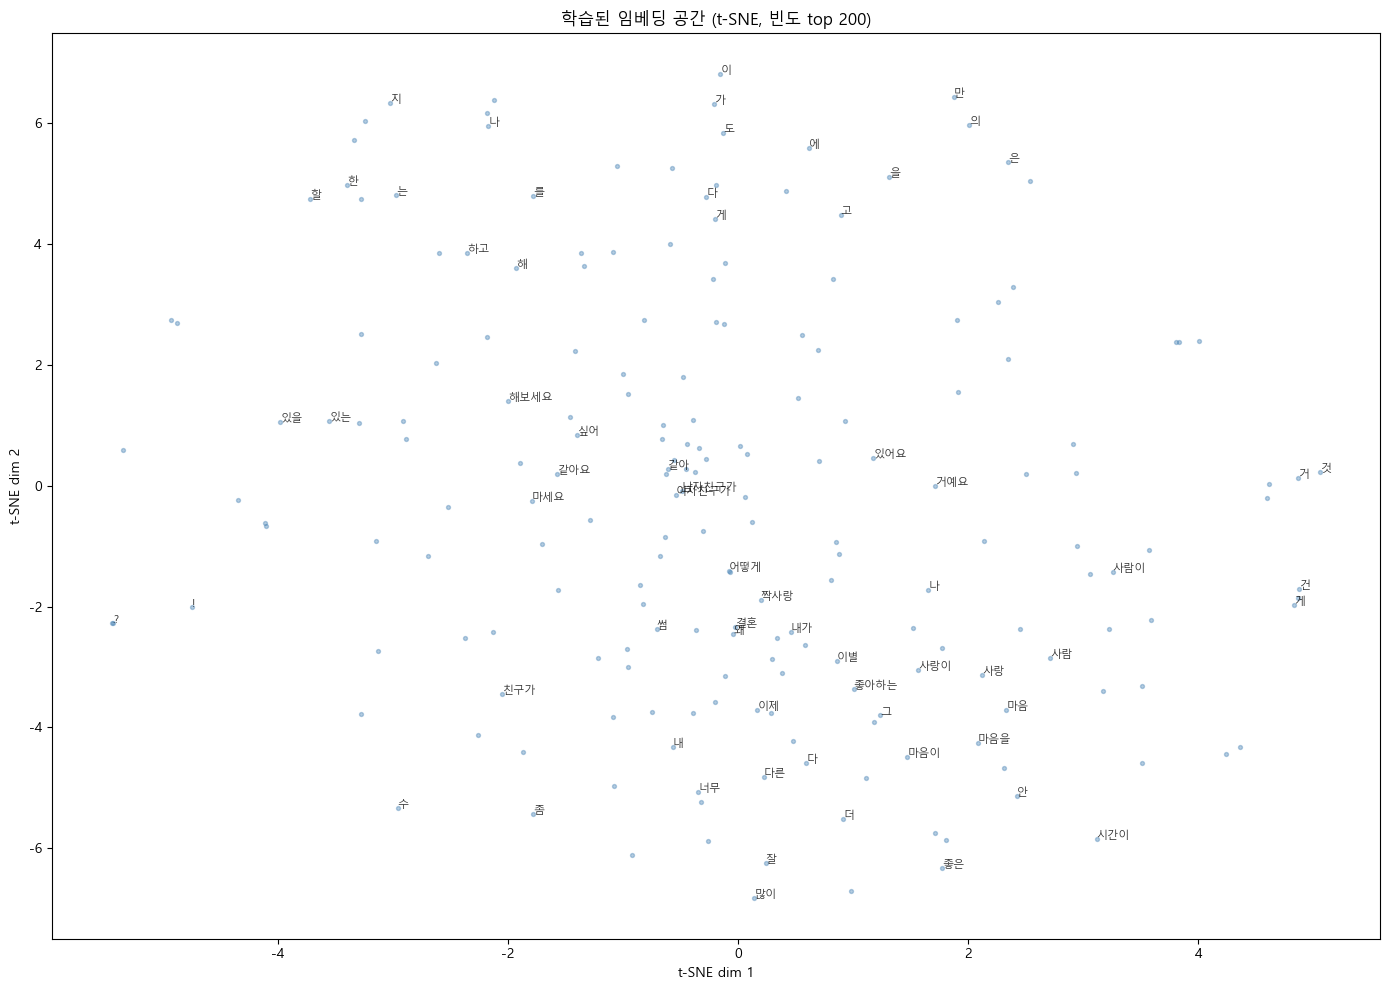

In [ ]:
# Cell 12: 임베딩 공간 t-SNE 시각화

# 빈도 top 200 토큰만 시각화
top_embs = embeddings[top_ids].numpy()
top_pieces = [sp.id_to_piece(tid).replace('▁','') for tid in top_ids]

# t-SNE
print("t-SNE 계산 중...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
coords = tsne.fit_transform(top_embs)
print("완료")

# 시각화
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.4, c='steelblue')

# 일부 단어에 라벨 (너무 많으면 지저분)
# 빈도 top 100 + 짚어볼 단어들
highlight_words = ["주식", "사장", "기말고사", "결혼", "외로", "사랑", "치킨", "여행",
                   "맛있", "기분", "마음", "스트레스", "친구", "회사", "공부"]

for i, piece in enumerate(top_pieces):
    if i < 60 or any(h in piece for h in highlight_words):
        ax.annotate(piece, (coords[i,0], coords[i,1]), 
                    fontsize=8, alpha=0.8, fontfamily='Malgun Gothic')

ax.set_title(f'학습된 임베딩 공간 (t-SNE, 빈도 top {len(top_ids)})', fontfamily='Malgun Gothic')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

### 어텐션 맵 분석 

임베딩에서의 어느정도 유의미한 상관관계가 만들어졌기 때문에 어텐션에 문제가 있는게 아닐까 하는 의심을 시작했다. 
임베딩에서 상관관계가 꽤 만들어졌는데도 본적없는 문장에 대해서 응답이 이상했다는 점이 조금 의뭉스러웠기 때문이다. 

우선 어텐션 맵에서는 3가지를 중점적으로 봤다. 

1. [sep] 위치가 Q의 핵심 의미를 보는가? [sep]은 답변 생성 직전 시점이기 때문에 이 시점의 어텐션이 핵심 의미어에 쏠려있어야 한다고 생각했다. 

2. 레이어 깊이별 패턴 변화 이것은 레이별로 어텐션 역할이 자연스럽게 분화 되는지 확인하기 위함이었다. 

3. 헤드간 다양성 각자 다른 패턴을 참조하는가? 

### 특징 

1. 외로워 라는 토큰에는 모든 레이어가 외로워에 집중한것 
2. 기말고사 망했어 라는 문장에서는 기말고사를 잘게 쪼갠 서브워드들에 분산이 되었다. 하지만 부분정보라도 끌어모으려는 시도가 있었던 것으로 보인다. 
3. 주식 또 떨어졌어 라는 문장은 이전 데이터셋에서는 완전히 관계가 없는 문장이기 때문에 주식, 떨어졌어 양쪽에 분산이 된다. 역시 의미를 잡지는 못한다. 

- 학습된 토큰에는 정확히 집중을 하지만 학습이 되지 않는 토큰에는 분산과 회피가 일어난다. 
- 임베딩과 어텐션에서의 매커니즘은 정상작동한다는 생각을 했음 여기서 문제는 데이터의 절대적인 양이라는 생각이 듬 



[잘 답한 Q]


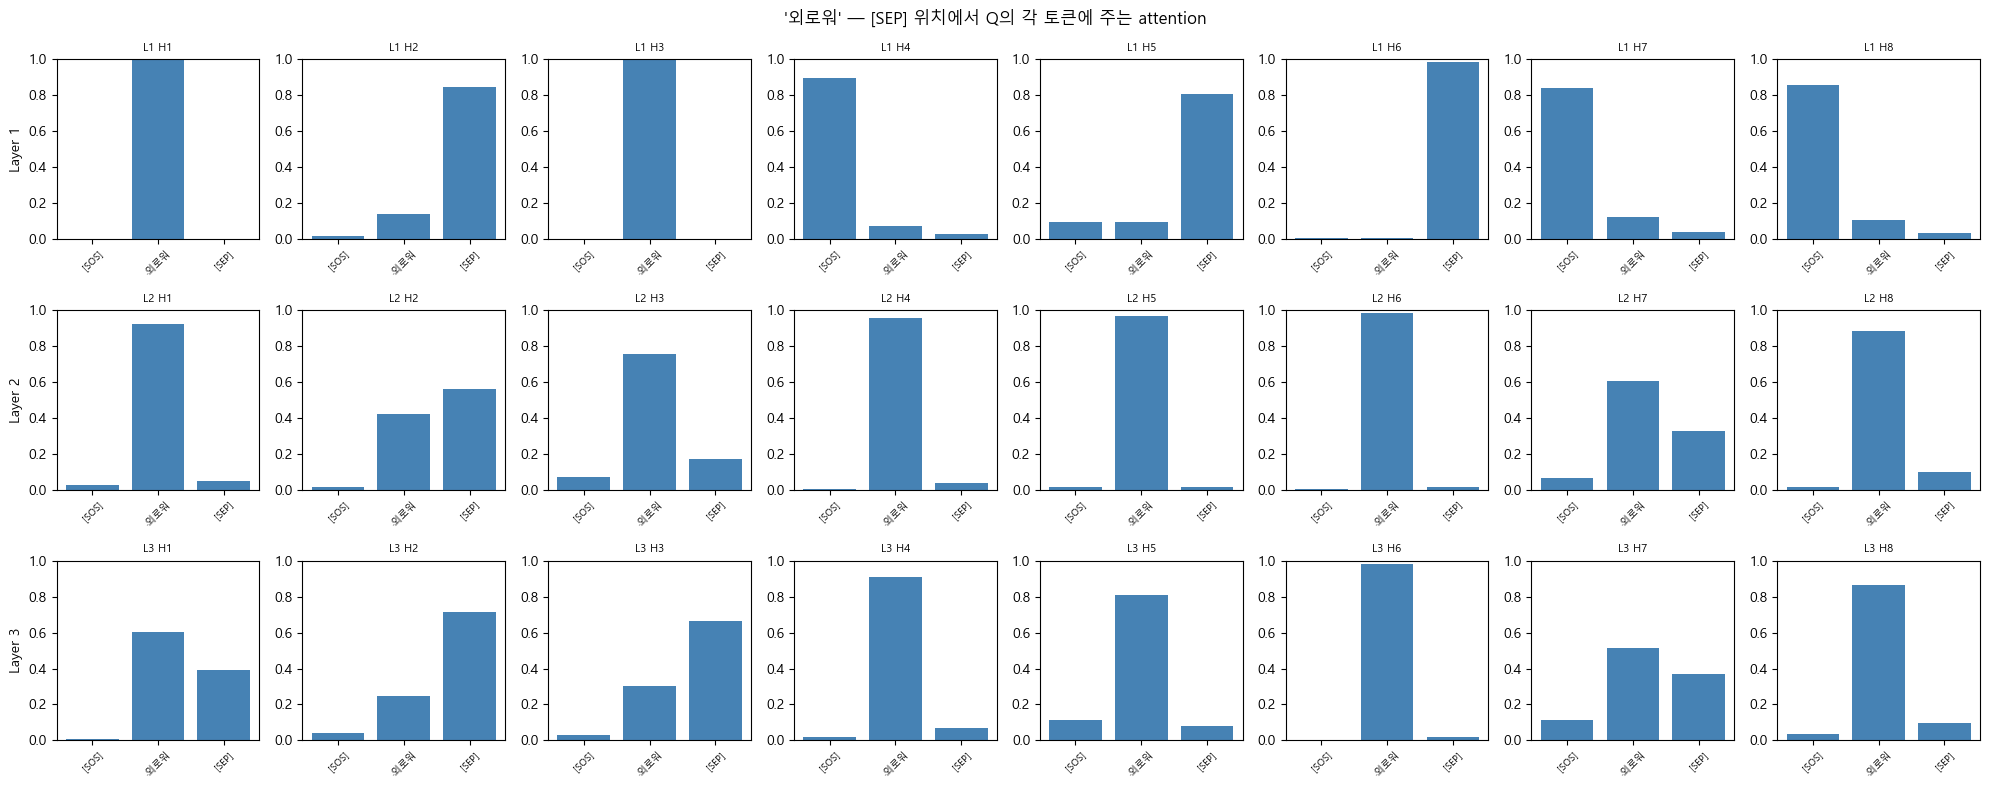


=== 평균 attention 분포 (all layers, all heads) ===
     [SOS]  0.137  ██████
      ·외로워  0.595  █████████████████████████████
     [SEP]  0.268  █████████████

[못 답한 Q]


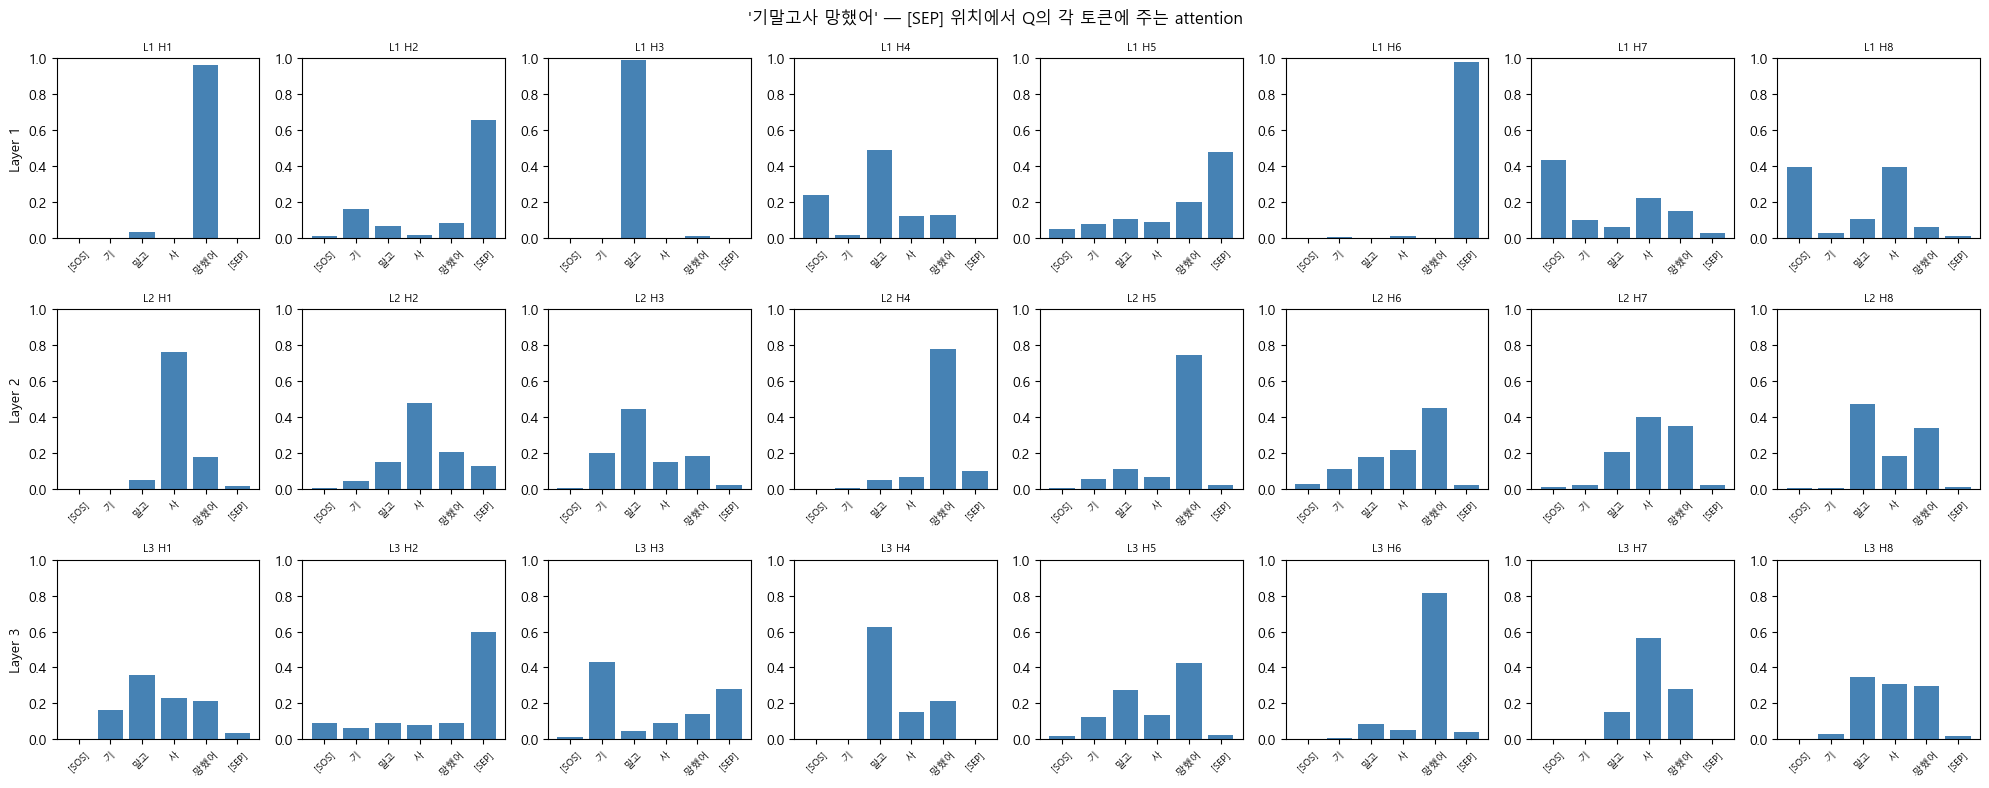


=== 평균 attention 분포 (all layers, all heads) ===
     [SOS]  0.054  ██
        ·기  0.069  ███
        말고  0.229  ███████████
         사  0.199  █████████
      ·망했어  0.304  ███████████████
     [SEP]  0.145  ███████

[또 다른 못 답한 Q]


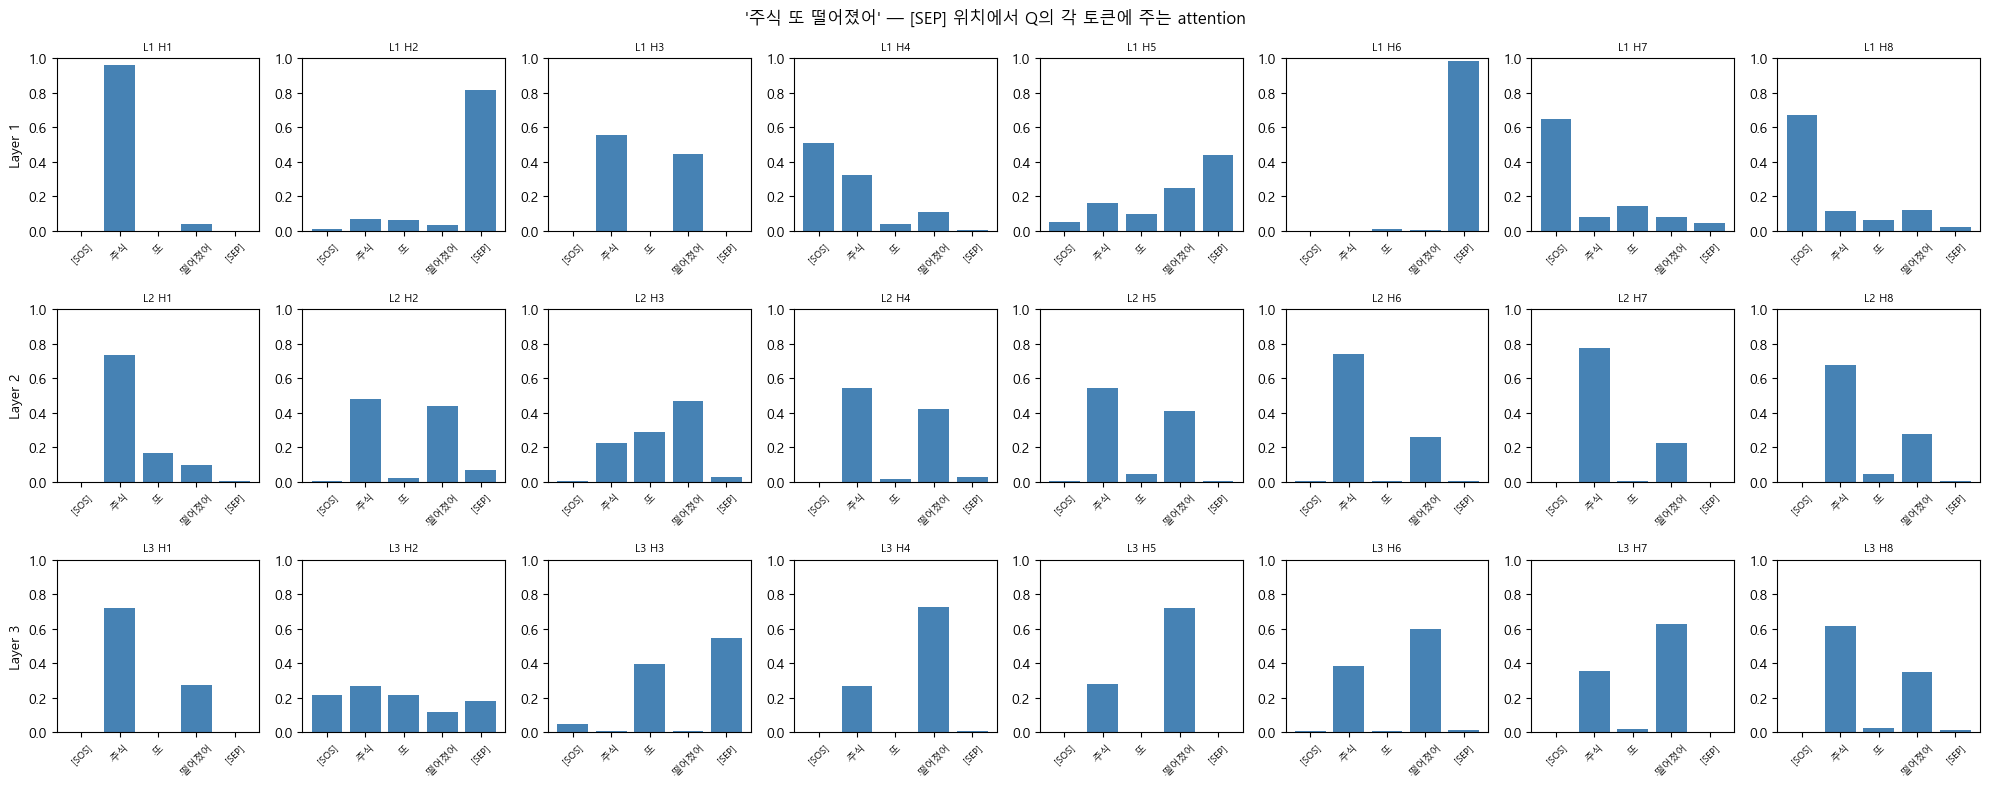


=== 평균 attention 분포 (all layers, all heads) ===
     [SOS]  0.091  ████
       ·주식  0.411  ████████████████████
        ·또  0.069  ███
     ·떨어졌어  0.295  ██████████████
     [SEP]  0.134  ██████


In [ ]:
# Cell 13: Attention Map 분석

import matplotlib.pyplot as plt
import numpy as np

@torch.no_grad()
def forward_with_attention(model, input_ids):
    """모델 forward를 재현하면서 모든 layer의 attention map 캡처"""
    B, L = input_ids.shape
    mask = make_attention_mask(input_ids, pad_id=PAD_ID)
    
    x = model.tok_embed(input_ids)
    cos, sin = model.rope(L)
    
    attn_maps = []
    
    for block in model.blocks:
        # Pre-LN self-attention 재현
        x_norm = block.norm1(x)
        mha = block.attn
        H, Hd = mha.num_heads, mha.head_dim
        
        q = mha.wq(x_norm).view(B, L, H, Hd).transpose(1, 2)
        k = mha.wk(x_norm).view(B, L, H, Hd).transpose(1, 2)
        v = mha.wv(x_norm).view(B, L, H, Hd).transpose(1, 2)
        
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) * mha.scale
        scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn_maps.append(attn.detach())   # 캡처
        
        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, L, mha.d_model)
        out = mha.wo(out)
        
        x = x + out
        x = x + block.ffn(block.norm2(x))
    
    return attn_maps   # [(B, H, L, L)] × num_layers


def visualize_attention(question, model, sp):
    """Q에 대한 [SEP] 위치의 attention 시각화"""
    model.eval()
    
    # 입력: [SOS] Q [SEP]
    q_ids = sp.encode_as_ids(normalize_text(question))
    input_ids = [SOS_ID] + q_ids + [SEP_ID]
    L = len(input_ids)
    
    input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
    attn_maps = forward_with_attention(model, input_tensor)
    
    # 토큰 라벨
    tokens = [sp.id_to_piece(i).replace('▁', '·') for i in input_ids]
    sep_pos = L - 1   # [SEP] 위치
    
    # 시각화: layer 3개 × head 8개의 [SEP] 위치 attention
    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    fig.suptitle(f"'{question}' — [SEP] 위치에서 Q의 각 토큰에 주는 attention",
                 fontfamily='Malgun Gothic', fontsize=12)
    
    for layer_idx, attn in enumerate(attn_maps):
        # attn: (1, H, L, L). [SEP] row만: (H, L)
        sep_attn = attn[0, :, sep_pos, :].cpu().numpy()
        
        for head_idx in range(8):
            ax = axes[layer_idx, head_idx]
            weights = sep_attn[head_idx]
            ax.bar(range(L), weights, color='steelblue')
            ax.set_xticks(range(L))
            ax.set_xticklabels(tokens, rotation=45, fontsize=7, fontfamily='Malgun Gothic')
            ax.set_title(f'L{layer_idx+1} H{head_idx+1}', fontsize=8)
            ax.set_ylim(0, 1)
            if head_idx == 0:
                ax.set_ylabel(f'Layer {layer_idx+1}', fontfamily='Malgun Gothic')
    
    plt.tight_layout()
    plt.show()
    
    # 추가: 평균 attention pattern
    print(f"\n=== 평균 attention 분포 (all layers, all heads) ===")
    all_attn = torch.cat(attn_maps, dim=1)  # (1, total_heads, L, L)
    mean_attn = all_attn[0, :, sep_pos, :].mean(dim=0).cpu().numpy()
    for tok, w in zip(tokens, mean_attn):
        bar = '█' * int(w * 50)
        print(f"  {tok:>8}  {w:.3f}  {bar}")


# ====== 비교 분석 ======
print("=" * 70)
print("[잘 답한 Q]")
print("=" * 70)
visualize_attention("외로워", model, sp)

print("\n" + "=" * 70)
print("[못 답한 Q]")
print("=" * 70)
visualize_attention("기말고사 망했어", model, sp)

print("\n" + "=" * 70)
print("[또 다른 못 답한 Q]")
print("=" * 70)
visualize_attention("주식 또 떨어졌어", model, sp)

### 데이터 증강 

우선 데이터셋이 모자라다는 것을 결론으로 내리고 데이터량을 늘릴  수 있는 방법을 생각해본다. 
12k 에서 최소 18k 물론 새로운 데이터셋을 받아도 되겠지만 데이터 증강이 루브릭 기준이기 때문에 최대한 증강쪽으로 가닥을 잡았다. 
가장 큰 문제는 데이터셋 자체가 이미 편향이 있는 데이터라는 것이었다. 숫자로 라벨링 되어있는 데이터셋은 특정 태스크에 최적화 되어있었기 때문에 다른 지식이나 대화주제로 들어가면 완전히 답을 하지 못하는 문제가 생기기 때문이다. 

결국 우선적으로 처리 할 일은 임베딩에서의 각 토큰들의 의미영역을 조금 더 넓히는 것을 목표로 삼았다. 
선택지는 3개 정도가 있었다 

1. 다른 데이터셋을 추가 - 가장 안전 효과도 확실 
2. LLM합성 - Q를 주고 새로운 A를 만든다. LLM호출비용과 함께 품질검수가 필수적이게 됨 
3. KoBERT MLM (선택)
4. Lexical Sub


하지만 노드는 Word2Vec 기반 Lexical Substitution을 제시한다. 이 방식은 분포적 유사성을 학습하므로 반의어가 유사 단어로 잡히는 함정이 있다('외로워' ↔ '행복해'가 같은 문맥에서 함께 등장). 또한 정적 임베딩이라 문장 문맥과 무관한 치환을 한다. 따라서 문맥 임베딩 기반 KoBERT MLM 치환을 사용한다. 한 문장당 [MASK] 1개로 BERT의 동시 마스킹 품질 저하를 회피하고, top-k 샘플링으로 다양성을 확보한다.



In [ ]:
pip install python-mecab-ko

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### KoBERT MLM 추론 준비 
python-mecab-ko으로 미리 mecab을 설치했다. 
노드는 정적 임베딩인 Word2Vec을 제시했었지만 아예 임베딩 모델을 통해서 단어 자체가 아니라 문장 안에서 그 자리가 들어갈 단어를 예측하는 
방식을 해보는게 어떨까 하는 생각을 했다. 
Mecab으로 어절 단위나 특정 단위의 마스킹 위치를 결정하고 그 자리를 가린 뒤 임베딩 모델이 적합한 후보단어를 채우는 방식으로 데이터 증강을 하는 방식이었다. 


In [ ]:
from mecab import MeCab
mecab = MeCab()
result = mecab.pos("오늘은 너무 외로워")
print(result)

[('오늘', 'NNG'), ('은', 'JX'), ('너무', 'MAG'), ('외로워', 'VA+EC')]


In [ ]:
# Cell: KoBERT MLM 추론 준비
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

# 모델 로드 (처음 실행 시 다운로드, ~400MB)
MLM_MODEL_NAME = "klue/bert-base"
mlm_tokenizer = AutoTokenizer.from_pretrained(MLM_MODEL_NAME)
mlm_model = AutoModelForMaskedLM.from_pretrained(MLM_MODEL_NAME)
mlm_model.eval()

# GPU 있으면 올리기 (없어도 됨, CPU도 동작)
mlm_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlm_model = mlm_model.to(mlm_device)

print(f"MLM model loaded on {mlm_device}")
print(f"Mask token: {mlm_tokenizer.mask_token}")  # [MASK]
print(f"Mask token id: {mlm_tokenizer.mask_token_id}")

c:\Users\akals\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 11138.05it/s]
[transformers] BertForMaskedLM LOAD REPORT from: klue/bert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MLM model loaded on cuda
Mask token: [MASK]
Mask token id: 4


### MLM추론 

실제 KoBERT 가 마스킹된 부분에 대해 추론을 잘 해주는지 검증해보는 단계 
[MASK]가 들어간 문장을 받아 TOPK 후보 단어를 반환하게 만들었다. 

테스트 해보니 몇가지 문제점이 있었다. 
특수문자나 특수 태그 서브워드 조각이 후보에 포함되거나 원본 단어가 들어가기도 했기 때문이다. 
최종적으로 top-5 후보 중 원본을 제외하고 비복원 무작위 샘플링한다.

In [ ]:
# Cell: MLM 추론 함수

@torch.no_grad()
def predict_mask_topk(masked_sentence: str, top_k: int = 5) -> list[str]:
 
    # 1) 텍스트를 BERT 토큰 ID로 변환
    inputs = mlm_tokenizer(masked_sentence, return_tensors='pt').to(mlm_device)
    
    # 2) [MASK] 토큰의 위치 찾기
    mask_token_id = mlm_tokenizer.mask_token_id  # 4
    mask_positions = (inputs['input_ids'][0] == mask_token_id).nonzero(as_tuple=True)[0]
    
    if len(mask_positions) == 0:
        return []  
    
    mask_pos = mask_positions[0].item() 
    
    # 3) 모델 forward
    outputs = mlm_model(**inputs)
    
    # 4) [MASK] 위치의 logits만 슬라이스
    mask_logits = outputs.logits[0, mask_pos]
    
    # 5) top-k 토큰 ID 뽑기
    top_k_ids = torch.topk(mask_logits, top_k).indices.tolist()
    
    # 6) 토큰 ID → 문자열로 변환
    top_k_tokens = [mlm_tokenizer.decode([tid]).strip() for tid in top_k_ids]
    
    return top_k_tokens


# 테스트
test_sentences = [
    "오늘은 너무 [MASK]",
    "[MASK] 외로워",
    "당신이 [MASK] 보고싶어",
]

for s in test_sentences:
    candidates = predict_mask_topk(s, top_k=5)
    print(f"입력: {s}")
    print(f"후보: {candidates}")
    print()

입력: 오늘은 너무 [MASK]
후보: ['[UNK]', '추워', '좋아', '더워', '더워서']

입력: [MASK] 외로워
후보: ['너무', '#', '넘', '(', '아']

입력: 당신이 [MASK] 보고싶어
후보: ['너무', '더', '너무너무', '정말', '진짜']



### 필터링 조건과 추론 함수를 구현 

is_valid_candidate은 후보단어의 유효성을 판별한다. 특정 토근이 있으면 필터링 
predict_mask_topk_filtered 이것은 필터링 적용된 TOPK추론
마스크 위치 찾기는 input_ids == mask_token_id로 비교를 통해 마스크 토큰의 인덱스를 획득 

In [ ]:
import re

def is_valid_candidate(token: str, original_word: str) -> bool:
    if token == '[UNK]':
        return False
    if token == original_word: 
        return False
    if not re.search(r'[가-힣a-zA-Z]', token):  
        return False
    if token.startswith('##'):  
        return False
    return True


@torch.no_grad()
def predict_mask_topk_filtered(masked_sentence: str, original_word: str, top_k: int = 10) -> list[str]:

    inputs = mlm_tokenizer(masked_sentence, return_tensors='pt').to(mlm_device)
    mask_pos = (inputs['input_ids'][0] == mlm_tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
    
    if len(mask_pos) == 0:
        return []
    
    outputs = mlm_model(**inputs)
    mask_logits = outputs.logits[0, mask_pos[0].item()]
    
    top_ids = torch.topk(mask_logits, top_k).indices.tolist()
    tokens = [mlm_tokenizer.decode([tid]).strip() for tid in top_ids]
    
    # 필터링
    valid = [t for t in tokens if is_valid_candidate(t, original_word)]
    
    return valid[:5]  


# 테스트
print(predict_mask_topk_filtered("오늘은 너무 [MASK]", "외로워"))
print(predict_mask_topk_filtered("[MASK] 외로워", "오늘은"))
print(predict_mask_topk_filtered("당신이 [MASK] 보고싶어", "너무"))

['추워', '좋아', '더워', '더워서', '슬퍼']
['너무', '넘', '아', '존나', '나']
['더', '너무너무', '정말', '진짜', '넘']


### 마스킹 위치 결정 

Mecab으로 어절을 분석해 부사위치만 마스킹 후보로 골랐다. 
명사, 동사, 형용사 등을 활용해봤지만 변경했을 때 의미가 많이 달라지는 값이 나왔기 때문이다. 
이건 해당 임베딩 모델인 KoBERT에서는 문맥의 적합성만 보기 때문에 완전히 반대의 의미를 가진 값이 나오기도 했기 때문이다. 
KoBERT는 문맥에 적합한 단어를 채워주지만, 그게 의미적으로 동등한 단어를 보장하지는 않는다. 
'보고싶어' 자리에 '싫어'가 들어가도 문법적으론 자연스러우니까.
그래서 최종적으로 선택한건 부사만 마스킹 하는 작업이었다. 


In [ ]:
from mecab import MeCab
import random

mecab = MeCab()

# 마스킹 대상 품사 태그
MASKABLE_POS = {
    'MAG',   # 일반부사 (너무, 진짜, 정말, 매우)
    'MAJ',   # 접속부사 (그리고, 하지만, 그래서)
}

def find_maskable_eojeol_indices(sentence: str) -> list[int]:

    eojeols = sentence.split()
    candidates = []
    
    for idx, eojeol in enumerate(eojeols):
        # 어절 안의 형태소들 분석
        morphs = mecab.pos(eojeol)
   
        for word, tag in morphs:
            tag_parts = tag.split('+') 
            if any(t in MASKABLE_POS for t in tag_parts):
                candidates.append(idx)
                break  
    
    return candidates


# 테스트
test_sentences = [
    "오늘은 너무 외로워",
    "그리고 잘 지내",
    "당신이 너무 보고싶어",
    "ㅋㅋ 진짜",
]

for s in test_sentences:
    indices = find_maskable_eojeol_indices(s)
    eojeols = s.split()
    candidates = [eojeols[i] for i in indices]
    print(f"문장: {s}")
    print(f"  후보 어절: {candidates}")

문장: 오늘은 너무 외로워
  후보 어절: ['너무']
문장: 그리고 잘 지내
  후보 어절: ['그리고', '잘']
문장: 당신이 너무 보고싶어
  후보 어절: ['너무']
문장: ㅋㅋ 진짜
  후보 어절: ['진짜']


### 100개의 샘플을 우선 변환 
전체 12k를 한번에 증강하기 전 무작위로 100개를 뽑아 결과를 직접 확인해 봤다. 
변환된 내용 자체의 품질은 적절했다고 생각했다. 
부사만 변경하기 때문에 영향이 적었던 것도 있었지만 QA간의 일관성이 깨지지 않았기 때문이다. 
다만 증강 성공률은 29% 32%로 예상보다 낮은 수치를 보였다. 

이것은 송영숙 데이터는 짧은 문장이 많아 부사가 아예 없는 문장이 많았기 때문이다. 
그래서 이 결과를 바탕으로 변종의 수를 K = 2 까지 늘려 양을 보강하기로 한다. 
Top -5 후보 중에서 선택할수 있는 부사의 갯수를 하나 더 늘리는 방식이다. 

In [ ]:
# Cell: 100개 샘플 증강 검수

import random
import pandas as pd

random.seed(42)  # 재현 가능하게

# 100개 무작위 샘플링
sample_df = df.sample(n=100, random_state=42).reset_index(drop=True)

# 결과 담을 리스트
inspection_results = []

for i, row in sample_df.iterrows():
    q_orig = row['Q']
    a_orig = row['A']
    
    q_aug = augment_sentence(q_orig)  
    a_aug = augment_sentence(a_orig)
    
    inspection_results.append({
        '#': i,
        'Q_원본': q_orig,
        'Q_변종': q_aug if q_aug else '[증강불가]',
        'A_원본': a_orig,
        'A_변종': a_aug if a_aug else '[증강불가]',
    })

inspection_df = pd.DataFrame(inspection_results)

# 보기 좋게 출력 설정
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)

# 1차로 통계 먼저
total = len(inspection_df)
q_success = (inspection_df['Q_변종'] != '[증강불가]').sum()
a_success = (inspection_df['A_변종'] != '[증강불가]').sum()

print(f"전체 샘플: {total}")
print(f"Q 증강 성공: {q_success} ({q_success/total*100:.1f}%)")
print(f"A 증강 성공: {a_success} ({a_success/total*100:.1f}%)")
print()
print("--- 상세 결과 ---")
inspection_df

전체 샘플: 100
Q 증강 성공: 29 (29.0%)
A 증강 성공: 32 (32.0%)

--- 상세 결과 ---


,#,Q_원본,Q_변종,A_원본,A_변종
0,0,죽을거 같네,[증강불가],나쁜 생각 하지 마세요.,[증강불가]
1,1,내일 시험이야,[증강불가],컨디션 조절 하세요.,[증강불가]
2,2,정말.내 자신이 싫다,내 자신이 싫다,자신은 사랑해주세요.,[증강불가]
3,3,이별후 네달째,[증강불가],바쁘게 살면서 잊어가요.,[증강불가]
4,4,쌍커풀 해볼까,[증강불가],눈은 기본이죠.,[증강불가]
5,5,내 생각 하나만 바꾸면 편할텐데.,[증강불가],하나 바꾸는 게 힘들지요.,[증강불가]
6,6,어떻게 살아가야 할까,[증강불가],태연하게 시작해보세요.,[증강불가]
7,7,발 아파,[증강불가],맥주병 같은 걸로 살살 문질러 주세요,맥주병 같은 걸로 살짝 문질러 주세요
8,8,썸 타는 것도 귀찮아.,[증강불가],그냥 사귀세요.,잘 사귀세요.
9,9,좋아하는 애랑 전화하면,[증강불가],즐거울 거예요.,[증강불가]


### 전체 데이터셋 증강 

지금까지 결정한 방법은 12k정체에 적용한다. 
Q치환본 +원본 A 
원본 Q + 치환본 A 
Q와 A를 동시에 바꾸면 완전히 의미분포에서 벗어날 것이라 생각해 한쪽씩만을 치환해주었다. 

여기서 치환된 값은 Top K = 2 까지이기 때문에 최대 2개의 변종이 나온다. 
랜덤시드를 따로 설정하고 난 뒤, 결과는 원본 11,823 + Q 변종 7,900 + A 변종 6,870 = 26,593 정도의 표본이 나왔다. 
이번 증강의 목적은 양보다는 임베딩 차원에서의 의미분포를 좀 더 효과적으로 학습 시키기 위한 것이 었기 때문에 그것을 우선시 한 결과였다. 



In [ ]:
# Cell: 전체 데이터셋 증강 (Q와 A 각각)

from tqdm import tqdm
import random

random.seed(42)
K = 2

augmented_rows = []

# 1) 원본 그대로 추가
for _, row in df.iterrows():
    augmented_rows.append({'Q': row['Q'], 'A': row['A'], 'source': 'original'})

# 2) Q 치환 변종 추가
print("Q 증강 중...")
q_aug_count = 0
for _, row in tqdm(df.iterrows(), total=len(df)):
    q_variants = augment_sentence_multi(row['Q'], k=K)
    for q_var in q_variants:
        augmented_rows.append({'Q': q_var, 'A': row['A'], 'source': 'Q_aug'})
        q_aug_count += 1

# 3) A 치환 변종 추가
print("A 증강 중...")
a_aug_count = 0
for _, row in tqdm(df.iterrows(), total=len(df)):
    a_variants = augment_sentence_multi(row['A'], k=K)
    for a_var in a_variants:
        augmented_rows.append({'Q': row['Q'], 'A': a_var, 'source': 'A_aug'})
        a_aug_count += 1

# DataFrame 조립
df_augmented = pd.DataFrame(augmented_rows)

# 통계
print(f"\n=== 증강 완료 ===")
print(f"원본: {len(df)}")
print(f"Q 변종: {q_aug_count}")
print(f"A 변종: {a_aug_count}")
print(f"전체: {len(df_augmented)}")
print(f"\n증강 비율: {len(df_augmented) / len(df):.2f}배")

Q 증강 중...


100%|██████████| 11823/11823 [00:39<00:00, 300.05it/s]


A 증강 중...


100%|██████████| 11823/11823 [00:49<00:00, 239.48it/s]


=== 증강 완료 ===
원본: 11823
Q 변종: 7900
A 변종: 6870
전체: 26593

증강 비율: 2.25배


In [ ]:
# 증강 결과 저장 — 나중에 다시 안 돌려도 됨
df_augmented.to_csv('chatbot_augmented.csv', index=False, encoding='utf-8-sig')
print(f"저장 완료: chatbot_augmented.csv ({len(df_augmented)} rows)")

저장 완료: chatbot_augmented.csv (26593 rows)


In [ ]:
# 증강 데이터 로드 
import pandas as pd

df_aug = pd.read_csv('chatbot_augmented.csv', encoding='utf-8-sig')
print(f"증강 데이터 로드: {len(df_aug)} rows")
print(f"컬럼: {df_aug.columns.tolist()}")
print(f"\nsource별 분포:")
print(df_aug['source'].value_counts())

증강 데이터 로드: 26593 rows
컬럼: ['Q', 'A', 'source']

source별 분포:
source
original    11823
Q_aug        7900
A_aug        6870
Name: count, dtype: int64


### 데이터 파이프라인 & 모델 & 학습

기존 설계한 데이터 파이프라인과 트랜스포머 모델을 그대로 재사용 한다. 
변경점은 입력 데이터를 `df_aug`(26,593 rows)로 교체한 것과 토크나이저를 증강된 코퍼스로 재학습 시킨점이다. 

학습루프 역시 그대로, sp_aug 토크나이저로 진행 
모델 weight는 `best_model_aug.pt`로 별도 저장하여 원본 모델과 비교 가능하게 함.

다만 처음 학습 시 빠르게 ppl이 비정상적으로 확인하는 현상을 관찰했고 디버깅을 통해 input과 target의 shift가 빠져 있었다
shift를 추가한 뒤 정상적인 학습 곡선을 보였다. 

In [21]:
# SentencePiece 재학습 
import sentencepiece as spm

# 1) 증강 데이터로 코퍼스 파일 생성
with open('corpus_aug.txt', 'w', encoding='utf-8') as f:
    for q, a in zip(df_aug['Q'], df_aug['A']):
        f.write(str(q) + '\n')
        f.write(str(a) + '\n')

print(f"코퍼스 저장: corpus_aug.txt ({len(df_aug) * 2} 줄)")

# 2) SentencePiece 학습 (vocab_size, special token은 기존과 동일)
spm.SentencePieceTrainer.Train(
    input='corpus_aug.txt',
    model_prefix='chatbot_spm_aug',
    vocab_size=8000,                      
    model_type='bpe',
    pad_id=0, bos_id=1, eos_id=2, unk_id=3,
    user_defined_symbols=['[SEP]'],
    character_coverage=0.9995,
)

# 3) 로드
sp_aug = spm.SentencePieceProcessor()
sp_aug.load('chatbot_spm_aug.model')

PAD_ID = sp_aug.pad_id()
SOS_ID = sp_aug.bos_id()
EOS_ID = sp_aug.eos_id()
UNK_ID = sp_aug.unk_id()
SEP_ID = sp_aug.piece_to_id('[SEP]')

print(f"\nVocab size: {sp_aug.get_piece_size()}")
print(f"Special tokens — PAD:{PAD_ID}, SOS:{SOS_ID}, EOS:{EOS_ID}, UNK:{UNK_ID}, SEP:{SEP_ID}")


코퍼스 저장: corpus_aug.txt (53186 줄)

Vocab size: 8000
Special tokens — PAD:0, SOS:1, EOS:2, UNK:3, SEP:4


In [33]:
# Cell 36 다시 (인코딩 함수 수정)

import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

MAX_LEN = 64
IGNORE_INDEX = -100

def build_sample_aug(q, a):
    q_ids = sp_aug.encode_as_ids(str(q))
    a_ids = sp_aug.encode_as_ids(str(a))
    
    seq = [SOS_ID] + q_ids + [SEP_ID] + a_ids + [EOS_ID]
    
    if len(seq) > MAX_LEN:
        seq = seq[:MAX_LEN-1] + [EOS_ID]
    
    sep_pos = 1 + len(q_ids)
    a_start = sep_pos + 1
    
    pad_len = MAX_LEN - len(seq)
    seq = seq + [PAD_ID] * pad_len
    
    input_ids  = seq[:-1]   # 한 칸 shift
    target_ids = seq[1:]
    
    labels = []
    for i, tok in enumerate(target_ids):
        original_pos = i + 1
        if original_pos >= a_start and tok != PAD_ID:
            labels.append(tok)
        else:
            labels.append(IGNORE_INDEX)
    
    return input_ids, labels

# 전체 변환
all_inputs = []
all_labels = []
for q, a in zip(df_aug['Q'], df_aug['A']):
    inp, lab = build_sample_aug(q, a)
    all_inputs.append(inp)
    all_labels.append(lab)

input_tensor_aug = torch.tensor(all_inputs, dtype=torch.long)
label_tensor_aug = torch.tensor(all_labels, dtype=torch.long)

print(f"input shape: {input_tensor_aug.shape}")
print(f"label shape: {label_tensor_aug.shape}")

# Split
dataset_aug = TensorDataset(input_tensor_aug, label_tensor_aug)
n_train = int(len(dataset_aug) * 0.9)
n_valid = len(dataset_aug) - n_train
train_ds_aug, valid_ds_aug = random_split(
    dataset_aug, [n_train, n_valid],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_aug = DataLoader(valid_ds_aug, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds_aug)}, Valid: {len(valid_ds_aug)}")

input shape: torch.Size([26593, 63])
label shape: torch.Size([26593, 63])
Train: 23933, Valid: 2660


In [27]:
# 모델 클래스가 살아있는지 확인
try:
    test = TransformerChatbot  # 또는 너가 정의한 클래스 이름
    print("모델 클래스 OK")
except NameError:
    print("모델 클래스 없음 — 정의 셀 다시 실행 필요")

모델 클래스 OK


In [ ]:
# 모델 생성 + 학습 (증강 데이터)
import math, time
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 하이퍼파라미터 (기존 노트북 값으로 맞춰)
VOCAB_SIZE = sp_aug.get_piece_size()
D_MODEL = 256          
NUM_HEADS = 4          
NUM_LAYERS = 4         
D_FF = 1024           
DROPOUT = 0.1
MAX_LEN_MODEL = MAX_LEN  

EPOCHS = 20            
LR = 5e-4              
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
GRAD_CLIP = 1.0

# 모델 생성
model_aug = TransformerChatbot(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_seq_len=MAX_LEN_MODEL,   
    dropout=DROPOUT,
        pad_id=PAD_ID,              
).to(device)

n_params = sum(p.numel() for p in model_aug.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}")

# Optimizer
optimizer = AdamW(model_aug.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Warmup + Cosine 스케줄러
total_steps = len(train_loader_aug) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX, label_smoothing=LABEL_SMOOTHING)

# 학습 기록
history_aug = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_val_loss = float('inf')

print(f"Total steps: {total_steps}, Warmup: {warmup_steps}")
print(f"Device: {device}\n")

# 학습 루프
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    
    # Train
    model_aug.train()
    train_loss_sum = 0.0
    for batch in train_loader_aug:
        input_ids, labels = [x.to(device) for x in batch]
        
        optimizer.zero_grad()
        logits = model_aug(input_ids)              # (B, L, V)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1))
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_aug.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        
        train_loss_sum += loss.item()
    
    train_loss = train_loss_sum / len(train_loader_aug)
    
    # Validation
    model_aug.eval()
    val_loss_sum = 0.0
    with torch.no_grad():
        for batch in valid_loader_aug:
            input_ids, labels = [x.to(device) for x in batch]
            logits = model_aug(input_ids)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1))
            val_loss_sum += loss.item()
    val_loss = val_loss_sum / len(valid_loader_aug)
    
    train_ppl = math.exp(min(train_loss, 20))
    val_ppl = math.exp(min(val_loss, 20))
    
    history_aug['train_loss'].append(train_loss)
    history_aug['val_loss'].append(val_loss)
    history_aug['train_ppl'].append(train_ppl)
    history_aug['val_ppl'].append(val_ppl)
    
    # Best model 저장 (별도 파일명)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_aug.state_dict(), 'best_model_aug.pt')
        marker = ' ✓ saved'
    else:
        marker = ''
    
    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"train_loss {train_loss:.4f} (ppl {train_ppl:.2f}) | "
          f"val_loss {val_loss:.4f} (ppl {val_ppl:.2f}) | "
          f"time {time.time()-t0:.1f}s{marker}")

print(f"\n=== 학습 완료 — best val_loss: {best_val_loss:.4f} ===")

Trainable params: 5,203,456
Total steps: 7480, Warmup: 748
Device: cuda

Epoch  1/20 | train_loss 7.0718 (ppl 1178.29) | val_loss 5.9544 (ppl 385.45) | time 13.5s ✓ saved
Epoch  2/20 | train_loss 5.6339 (ppl 279.76) | val_loss 5.3020 (ppl 200.74) | time 13.0s ✓ saved
Epoch  3/20 | train_loss 4.9076 (ppl 135.31) | val_loss 4.5575 (ppl 95.34) | time 13.1s ✓ saved
Epoch  4/20 | train_loss 4.0880 (ppl 59.62) | val_loss 3.9263 (ppl 50.72) | time 14.2s ✓ saved
Epoch  5/20 | train_loss 3.4134 (ppl 30.37) | val_loss 3.4692 (ppl 32.11) | time 13.9s ✓ saved
Epoch  6/20 | train_loss 2.9269 (ppl 18.67) | val_loss 3.1729 (ppl 23.88) | time 14.8s ✓ saved
Epoch  7/20 | train_loss 2.5871 (ppl 13.29) | val_loss 2.9738 (ppl 19.57) | time 14.6s ✓ saved
Epoch  8/20 | train_loss 2.3556 (ppl 10.54) | val_loss 2.8438 (ppl 17.18) | time 13.6s ✓ saved
Epoch  9/20 | train_loss 2.1882 (ppl 8.92) | val_loss 2.7700 (ppl 15.96) | time 14.5s ✓ saved
Epoch 10/20 | train_loss 2.0641 (ppl 7.88) | val_loss 2.7124 (ppl 1

### 학습 결과

best val_loss 2.6044 (PPL ≈ 13.5) 이므로 원본 모델의 ppl이 165였던과는 다르게 좋은 모습을 보이고 있었다 또한 학습/검증용의 로스율 차이도 1정도의 차이가 나기 때문에 이전과 비교했을 때 차이를 많이 줄인 모습이었고 과적합 신호역시 많이 해소된 모습이다. 

하지만 이것은 학습상의 신호일 뿐이지 챗봇은 역시 직접 테스트를 통해 얼마나 자연스러운 응답을 하는지가 관건이라고 생각했기 때문에 
실제 모델에게 모델이 모르는 질문을 통해 어떤 응답을 내리는지 살펴보기로 하고 함수를 만든다. 
결과는 꽤 흥미로웠는데 그리드 쪽의 응답을 보면 전혀 다른 카테고리의 이야기인데도 꽤나 자연스러운 응답을 하지 않나...하는 느낌이 들었다는 것이다. 

물론 치킨 이야기에서는 여전히 뚱딴지 같은 소리를 하지만 개인적으로는 외롭다는 말에 외로우니까 사람이다. 라는 응답은 내 예상외였다. 
전체적으로 응답의 품질이 많이 오르지 않았나 그런 생각을 한다. 


In [ ]:
# Cell 38: 증강 모델 채팅 함수

@torch.no_grad()
def chat_aug(question, max_new_tokens=30, strategy='greedy', temperature=1.0, top_k=10):
    """
    증강 모델로 응답 생성
    strategy: 'greedy' | 'sample'
    """
    model_aug.eval()
    
    # 1) Q를 토큰화 → [SOS] Q [SEP] 까지 만들기
    q_ids = sp_aug.encode_as_ids(question)
    input_ids = [SOS_ID] + q_ids + [SEP_ID]
    input_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    # 2) 자기회귀 생성
    for _ in range(max_new_tokens):
        # 현재까지의 토큰으로 다음 토큰 예측
        logits = model_aug(input_ids)           
        next_logits = logits[0, -1, :]          
        
        if strategy == 'greedy':
            next_id = next_logits.argmax().item()
        else:  # sample
            next_logits = next_logits / temperature
            top_values, top_indices = torch.topk(next_logits, top_k)
            probs = torch.softmax(top_values, dim=-1)
            choice = torch.multinomial(probs, num_samples=1)
            next_id = top_indices[choice].item()
        
        # EOS면 중단
        if next_id == EOS_ID:
            break
        
        # 토큰 추가
        next_tensor = torch.tensor([[next_id]], dtype=torch.long).to(device)
        input_ids = torch.cat([input_ids, next_tensor], dim=1)
        
        # MAX_LEN 초과 방지
        if input_ids.size(1) >= MAX_LEN:
            break
    
    # 3) 생성된 부분만 디코딩 (Q와 SEP 제외, A 부분만)
    generated_ids = input_ids[0].tolist()
    # [SEP] 이후 토큰들이 답변
    if SEP_ID in generated_ids:
        sep_pos = generated_ids.index(SEP_ID)
        answer_ids = generated_ids[sep_pos + 1:]
    else:
        answer_ids = generated_ids
    
    answer = sp_aug.decode_ids(answer_ids)
    return answer


# 모델 best weight 로드
model_aug.load_state_dict(torch.load('best_model_aug.pt'))
print("best_model_aug 로드 완료\n")

# 채팅 테스트
test_questions = [
    "오늘 너무 외로워",
    "당신이 보고싶어",
    "치킨 먹고 싶다",
    "월요일이 싫어",
    "사장님이 또 갈궈",
    "라면 끓이는 중",
]

print("=== Greedy ===")
for q in test_questions:
    a = chat_aug(q, strategy='greedy')
    print(f"Q: {q}")
    print(f"A: {a}\n")

print("=== Sampling (top-10, T=0.8) ===")
for q in test_questions:
    a = chat_aug(q, strategy='sample', temperature=0.8, top_k=10)
    print(f"Q: {q}")
    print(f"A: {a}\n")

best_model_aug 로드 완료

=== Greedy ===
Q: 오늘 너무 외로워
A: 외로우니까 사람이다.

Q: 당신이 보고싶어
A: 그럴 수 있어요.

Q: 치킨 먹고 싶다
A: 그래봤자 상대방이 안 좋아할 거예요.

Q: 월요일이 싫어
A: 기분 탓인지 월요일은 좀 힘든 것 같아요.

Q: 사장님이 또 갈궈
A: 애정표현일 지도 몰라요.

Q: 라면 끓이는 중
A: 라면봉지 레시피 그대로 해보세요.

=== Sampling (top-10, T=0.8) ===
Q: 오늘 너무 외로워
A: 외로우니까 사람이다.

Q: 당신이 보고싶어
A: 그럴 수 있어요.

Q: 치킨 먹고 싶다
A: 그래 그래봤자 상대방이 안 좋아할 거예요.

Q: 월요일이 싫어
A: 기분 탓인지 탓인지 월요일은 좀 힘든 것 같아요.

Q: 사장님이 또 갈궈
A: 뭘 뭐든 쉬는 시간도 필요해요.

Q: 라면 끓이는 중
A: 라면봉지 레시피 그대로 해보세요.



### 임베딩 가시화 

이전 코드를 재활용해 임베딩 벡터간 이웃관계와 가시화를 통해 학습이 잘 되었는지 확인해 보려고 했다. 
원본 모델:

"주식" → sim 0.833, 0.832, 0.831
"외로" → sim 0.706, 0.682, 0.681
"치킨" → sim 0.737, 0.710, 0.704

→ sim 값이 높음 (0.7~0.8)
증강 모델:

"주식" → sim 0.471, 0.443
"외로" → sim 0.319, 0.303
"치킨" → sim 0.302, 0.301

→ sim 값이 낮음 (0.3~0.4)

이번 증강모델에서의 결과가 흥미러웠던 점은 이번에는 원본모델에서 값이 높아 
제대로 학습이 되지 않았다 생각한 토큰들의 값이 낮아지는 대신 
의미가 연결되기 시작했다는 점이었다. 

원본 모델 — sim 높지만 의미 무관:

"주식" → 오디션, 땅, 륜, 뻤... ← 완전 무관한 단어들
"외로" → 힘든데, 됨, 어른, 머리카락, 대화의, 볶 ← 무관
"치킨" → 업, 두려, 밟, 공부해야지, 마셔야지 ← 무관
"결혼" → 진정한, 활, 사귀기, 불행, 잊어야 ← 약간 관련은 있음

증강 모델 — sim 낮지만 의미 정합:

"결혼" → 현실, 사귄, 설레, 함께 ← 관계/결혼 영역
"외로" → 빈, 이제는, 헤어지, 무덤덤 ← 감정/상태 영역
"사랑" → 당신, 사랑을, 사랑은, 행동, 생각 ← 사랑 영역

원본의 높은 sim이 그저 랜덤으로 초기화 되어서 학습이 되지 않아 생긴 분포라면 
지금 증강후에 생기는 변화는 최소한 임베딩 공간에 분포가 조금씩 잡히기 시작했다는 신호이기 때문이다. 
실제로 분포시각화를 통해서 이전과 다르게 분포도가 조금 더 의미있게 잡히기 시작한 것 역시 확인해 볼수가 있었다. 


증강 모델 embedding shape: torch.Size([8000, 256])
분석 대상: 빈도 top 200 토큰
[증강 모델 — 의미적 이웃 검증]

'주식' (토큰: ['▁주식'], 첫 토큰 '▁주식' 기준)
  ▁주식으로           sim=0.471
  sns             sim=0.443
  렸다              sim=0.436
  ▁무사             sim=0.436
  ▁지루             sim=0.432
  ▁봤네             sim=0.430
  ▁아이디            sim=0.424
  ▁후유증            sim=0.419

'사장' (토큰: ['▁사', '장'], 첫 토큰 '▁사' 기준)
  ▁해              sim=0.280
  ▁하              sim=0.266
  ▁               sim=0.265
  ▁눈              sim=0.257
  ▁넓              sim=0.256
  ▁상              sim=0.255
  ▁타              sim=0.253
  ▁주              sim=0.249

'기말고사' (토큰: ['▁기', '말고', '사'], 첫 토큰 '▁기' 기준)
  ▁꿈              sim=0.294
  ▁감정             sim=0.257
  ▁주말             sim=0.256
  ▁리              sim=0.254
  ▁기본             sim=0.251
  ▁무              sim=0.249
  ▁나              sim=0.248
  ▁결정             sim=0.246

'결혼' (토큰: ['▁결혼'], 첫 토큰 '▁결혼' 기준)
  ▁현실             sim=0.294
  ▁사귄             sim=0.290
  ▁남았나봐요          sim=0.266
  

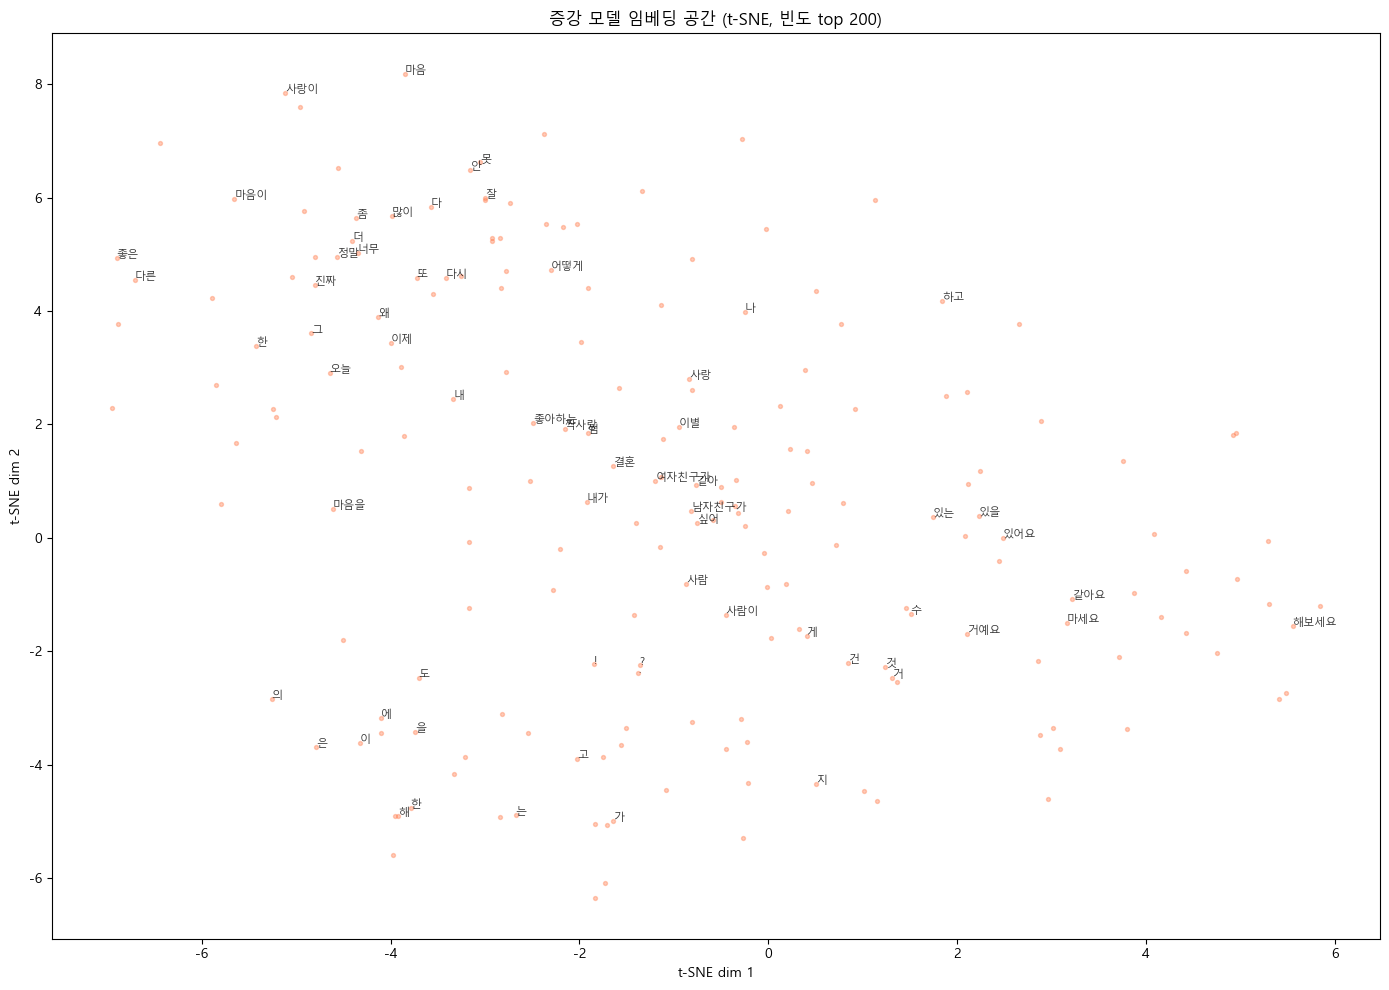

In [37]:
# Cell: 증강 모델 임베딩 진단 + t-SNE

import torch.nn.functional as F
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# 1) 증강 모델의 임베딩 가져오기
embeddings_aug = model_aug.tok_embed.weight.detach().cpu()
print(f"증강 모델 embedding shape: {embeddings_aug.shape}")

# 2) 토큰 빈도 (증강 데이터 기준)
counter_aug = Counter()
for q, a in zip(df_aug['Q'], df_aug['A']):
    counter_aug.update(sp_aug.encode_as_ids(str(q)))
    counter_aug.update(sp_aug.encode_as_ids(str(a)))

specials = {PAD_ID, SOS_ID, EOS_ID, UNK_ID, SEP_ID}
top_ids_aug = [tid for tid, _ in counter_aug.most_common(300) if tid not in specials][:200]
print(f"분석 대상: 빈도 top {len(top_ids_aug)} 토큰")


# 3) Nearest Neighbor 함수 (증강 버전)
def nearest_neighbors_aug(word, k=8):
    pieces = sp_aug.encode_as_pieces(word)
    ids = sp_aug.encode_as_ids(word)
    if len(ids) == 0:
        print(f"'{word}': 토큰화 실패")
        return
    
    target_id = ids[0]
    target_piece = pieces[0]
    target_emb = embeddings_aug[target_id].unsqueeze(0)
    
    sims = F.cosine_similarity(target_emb, embeddings_aug, dim=-1)
    for sid in [target_id] + list(specials):
        sims[sid] = -1
    
    top_k = sims.topk(k)
    
    print(f"\n'{word}' (토큰: {pieces}, 첫 토큰 '{target_piece}' 기준)")
    for sim, idx in zip(top_k.values, top_k.indices):
        piece = sp_aug.id_to_piece(idx.item())
        print(f"  {piece:<15} sim={sim.item():.3f}")


# 원본에서 짚어봤던 같은 단어들로 직접 비교 가능
print("=" * 60)
print("[증강 모델 — 의미적 이웃 검증]")
print("=" * 60)

for word in ["주식", "사장", "기말고사", "결혼"]:
    nearest_neighbors_aug(word)

print("\n" + "=" * 60)
print("[정상 작동 예상 단어들]")
print("=" * 60)
for word in ["외로", "사랑", "치킨", "여행"]:
    nearest_neighbors_aug(word)


# 4) t-SNE 시각화
print("\nt-SNE 계산 중...")
top_embs_aug = embeddings_aug[top_ids_aug].numpy()
top_pieces_aug = [sp_aug.id_to_piece(tid).replace('▁','') for tid in top_ids_aug]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
coords_aug = tsne.fit_transform(top_embs_aug)
print("완료")

# 시각화
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords_aug[:, 0], coords_aug[:, 1], s=8, alpha=0.4, c='coral')

highlight_words = ["주식", "사장", "기말고사", "결혼", "외로", "사랑", "치킨", "여행",
                   "맛있", "기분", "마음", "스트레스", "친구", "회사", "공부"]

for i, piece in enumerate(top_pieces_aug):
    if i < 60 or any(h in piece for h in highlight_words):
        ax.annotate(piece, (coords_aug[i,0], coords_aug[i,1]),
                    fontsize=8, alpha=0.8, fontfamily='Malgun Gothic')

ax.set_title(f'증강 모델 임베딩 공간 (t-SNE, 빈도 top {len(top_ids_aug)})', 
             fontfamily='Malgun Gothic')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()

### 마무리하며 

프로젝트의 핵심 가설은 단순했다. 
모델이 일반화, 혹은 제대로 된 학습을 한 것을 보기 위해서는 최종적으로 업데이트되는 임베딩 차원에서의 분포가 잡혀야 한다는 것 

1차 학습 후 모델은 모르는 질문에 대해서는 제대로 답하지 못하는 모습을 보였다. 
loss그래프를 봐서는 단순 과적합으로 보였지만 나는 학습이 제대로 되지 않았고, 그것을 임베딩 차원에서 확인할수 있다고 생각했다. 

NN분석에서는 흥미로운 패턴은 흔한 토큰은 sim이 낮으면서 의미적으로 정렬이 되어있고 특정 군집을 이루려는 모습이 있었지만 
드문 토큰에 대해서는 sim이 높은 값으로 나타나고 분포 역시 모호했었다. 

- 임베딩이 정규분포로 초기화ㅗ 되면 벡터들은 원점 근처로 모인다. 
- 학습이 충분하다면 벡터는 원점에서 벗어나면서 sim이 낮아지고 군집을 만들거나 의미가 정렬된다. 
- 토큰들이 원점 근처에 군집해 있는 것은 어쩌면 학습 업데이트가 부족했다는 신호일지도ㅗ. 

어텐션 마스크도 디버긴 했지만 매커니즘 자체에는 문제가 없다고 판단했었다. 

### 증강 

데이터 증강은 그저 양을 늘리는게 아닌 임베딩 차원에서의 분포를 더 넓게 잡아 각 토큰과 연결을 의미있게 만드는 것이 목적이었다. 
그것을 위해 결과적으로 부사를 마스킹 하는 방법이 여러 분포를 연결하는 다리역할을 해준게 아니었을까 

- 드문 토큰의 sim이 0.7~8 에서 0.3~4로 낮아짐 
- 이웃들이 의미 영역별로 군집을 이룸 "결혼" >> 현실, 설레, 함께 "외로">> 빈, 헤어지, 무덤덤 
- t-SNE에서 중앙 응집이 풀리고 의미 군집이 형성 

### 모자란 점 

증강을 쓰더라도 결국 데이터셋의 태스크가 좁기 때문에 학습 데이터에서 부족한 부분이 많았던것 같았다. 
증강 후에도 제대로 정렬이 안되거나 답하지 못한 문제들이 그 예시라 생각한다. 치킨, 주식 등등 
이는 결과적으로 데이터셋의 증강뿐마는 아닌 더 많은 데이터셋이 필요하다는 것을 보여준다 

